In [50]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime
from scipy import stats as sp_stats
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

In [51]:
US_EQUITY  = ['VIOV', 'MTUM', 'VBR']
ETF_GLOBAL = ['VEA', 'VWO', 'AGG', 'BNDX', 'GLD', 'VNQ', 'BTC-USD']
STOCKS     = ['MC.PA', 'ASML', 'NESN.SW', 'SIE.DE']
BENCHMARK  = ['VT', 'BNDW','AOR']
ALL_TICKERS = list(set(US_EQUITY + ETF_GLOBAL + STOCKS + BENCHMARK))
START = '2013-01-01'
END   = datetime.today().strftime('%Y-%m-%d')
raw = yf.download(ALL_TICKERS, start=START, end=END, auto_adjust=True, progress=True)['Close']
print(raw.shape)
print(raw.isna().sum().sort_values(ascending=False))

[*********************100%***********************]  17 of 17 completed

(4708, 17)
Ticker
BNDW       2770
BNDX       1445
MTUM       1413
NESN.SW    1350
VT         1340
VNQ        1340
VIOV       1340
VEA        1340
VBR        1340
AGG        1340
AOR        1340
GLD        1340
ASML       1340
VWO        1340
SIE.DE     1311
MC.PA      1283
BTC-USD     441
dtype: int64


## 1. Investment Policy Statement (IPS)

In [52]:
from IPython.display import Markdown, display

ips = '''
| Attribute | Detail |
|---|---|
| **Investor profile** | Individual — Private wealth |
| **Existing holding** | CHF 180,000 in AstraZeneca (Large Cap Healthcare, 3-year lock-up) |
| **Horizon** | Long-term — 33 years (retirement at 67) |
| **Risk tolerance** | Moderate-high (drawdowns > 20% accepted) |
| **Return objective** | Inflation + 4% net of fees, annualised |
| **Income needs** | Low — total return strategy |
| **Constraints** | Long-only · No leverage · TER < 0.5%/yr |
| **Factor tilts** | Small Cap · Value · High Momentum (US Equity sleeve) |
| **Reference currency** | CHF (unhedged USD/EUR exposures accepted) |
| **Cash constraint** | Min 5% in cash or equivalents (Swiss residence risk) |
'''
display(Markdown('### Investor Profile — Sofia Andersen\n' + ips))

### Investor Profile — Sofia Andersen

| Attribute | Detail |
|---|---|
| **Investor profile** | Individual — Private wealth |
| **Existing holding** | CHF 180,000 in AstraZeneca (Large Cap Healthcare, 3-year lock-up) |
| **Horizon** | Long-term — 33 years (retirement at 67) |
| **Risk tolerance** | Moderate-high (drawdowns > 20% accepted) |
| **Return objective** | Inflation + 4% net of fees, annualised |
| **Income needs** | Low — total return strategy |
| **Constraints** | Long-only · No leverage · TER < 0.5%/yr |
| **Factor tilts** | Small Cap · Value · High Momentum (US Equity sleeve) |
| **Reference currency** | CHF (unhedged USD/EUR exposures accepted) |
| **Cash constraint** | Min 5% in cash or equivalents (Swiss residence risk) |


## 2. Strategic Asset Allocation (SAA)

In [53]:
PORTFOLIO_TICKERS = list(dict.fromkeys(US_EQUITY + ETF_GLOBAL + STOCKS))
prices_raw  = raw[ALL_TICKERS].ffill().dropna()
prices=raw[PORTFOLIO_TICKERS].ffill().dropna().resample('W').last()
#               Conversion to weekly returns 
# We resample to the last price of each week (Friday) to avoid
# the overlapping effect caused by time zone differences between markets.
# Weekly log returns = the sum of daily log returns over the week,
# which is accurate and free from rebalancing bias.
weekly_prices  = prices_raw.resample('W').last()          # last spot for every weeks
weekly_returns = np.log(prices / prices.shift(1)).dropna()

# Annualization: 52 weeks instead of 252 days
ann_ret = weekly_returns.mean() * 52
ann_vol = weekly_returns.std()  * np.sqrt(52)

RF_PROXY = 0.03
sharpe_i = (ann_ret - RF_PROXY) / ann_vol

stats = pd.DataFrame({
    'Annualized returns': ann_ret,
    'Annualized volatility': ann_vol,
    'Individual Sharpe': sharpe_i
}).sort_values('Individual Sharpe', ascending=False)

print(f'Period  : {weekly_returns.index[0].date()} → {weekly_returns.index[-1].date()}')
print(f'Assets   : {len(PORTFOLIO_TICKERS)}   |   Obs hebdo : {len(weekly_returns)}')
print(f'( ~{len(weekly_returns)/52:.1f} ans)\n')
print(stats.round(4))

Period  : 2014-09-28 → 2026-05-24
Assets   : 14   |   Obs hebdo : 609
( ~11.7 ans)

         Annualized returns  Annualized volatility  Individual Sharpe
Ticker                                                               
BTC-USD              0.4490                 0.6703             0.6252
ASML                 0.2473                 0.3529             0.6157
MTUM                 0.1421                 0.1951             0.5743
GLD                  0.1078                 0.1513             0.5143
SIE.DE               0.1293                 0.2720             0.3650
MC.PA                0.1263                 0.2739             0.3516
VBR                  0.0900                 0.2139             0.2803
VEA                  0.0757                 0.1702             0.2687
VIOV                 0.0885                 0.2312             0.2531
VNQ                  0.0635                 0.2131             0.1572
VWO                  0.0539                 0.1830             0.1307
NESN.S

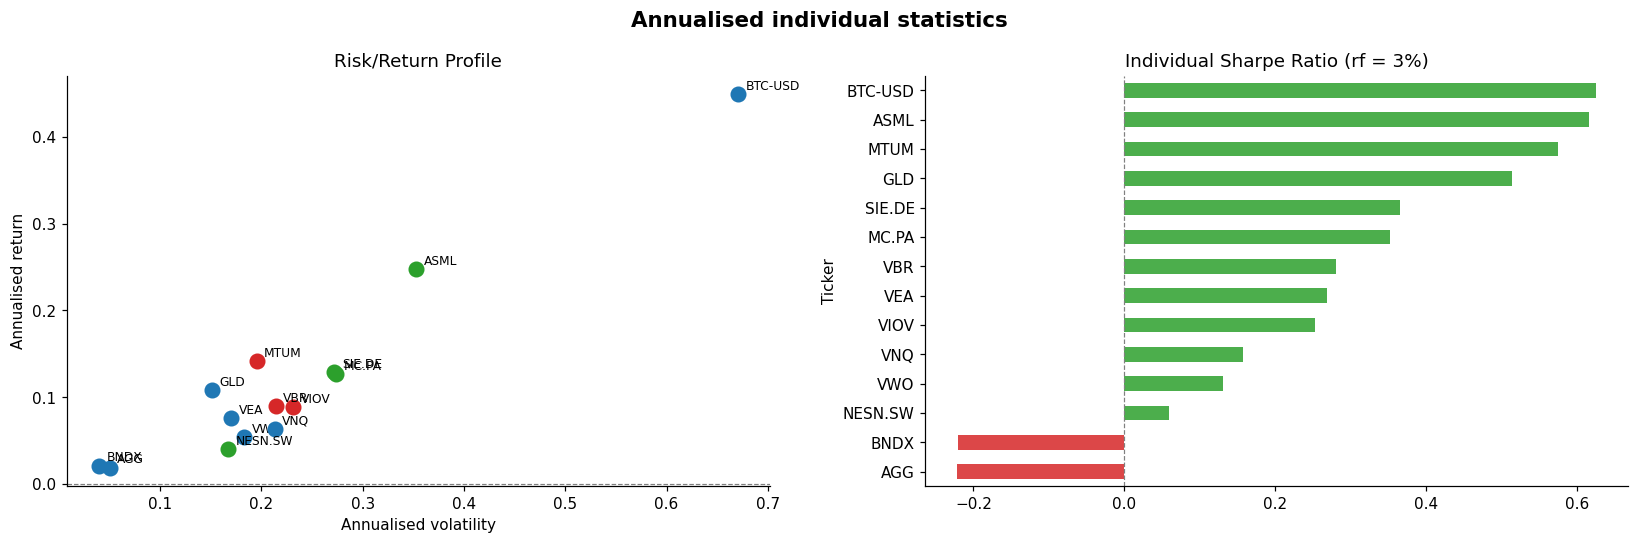

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Annualised individual statistics', fontsize=14, fontweight='bold')
ax1 = axes[0]
colors_group = (['#d62728']*3 + ['#1f77b4']*7 + ['#2ca02c']*4)
for t, c in zip(PORTFOLIO_TICKERS, colors_group):
    ax1.scatter(ann_vol[t], ann_ret[t], s=90, color=c, zorder=3)
    ax1.annotate(t, (ann_vol[t], ann_ret[t]), textcoords='offset points', xytext=(5,3), fontsize=8)
ax1.axhline(0, color='grey', lw=0.8, linestyle='--')
ax1.set_xlabel('Annualised volatility'); ax1.set_ylabel('Annualised return')
ax1.set_title('Risk/Return Profile')
ax2 = axes[1]
sharpe_sorted = stats['Individual Sharpe'].sort_values()
bar_colors = ['#d62728' if v < 0 else '#2ca02c' for v in sharpe_sorted]
sharpe_sorted.plot(kind='barh', ax=ax2, color=bar_colors, alpha=0.85)
ax2.axvline(0, color='grey', lw=0.8, linestyle='--')
ax2.set_title('Individual Sharpe Ratio (rf = 3%)')
plt.tight_layout(); plt.show()

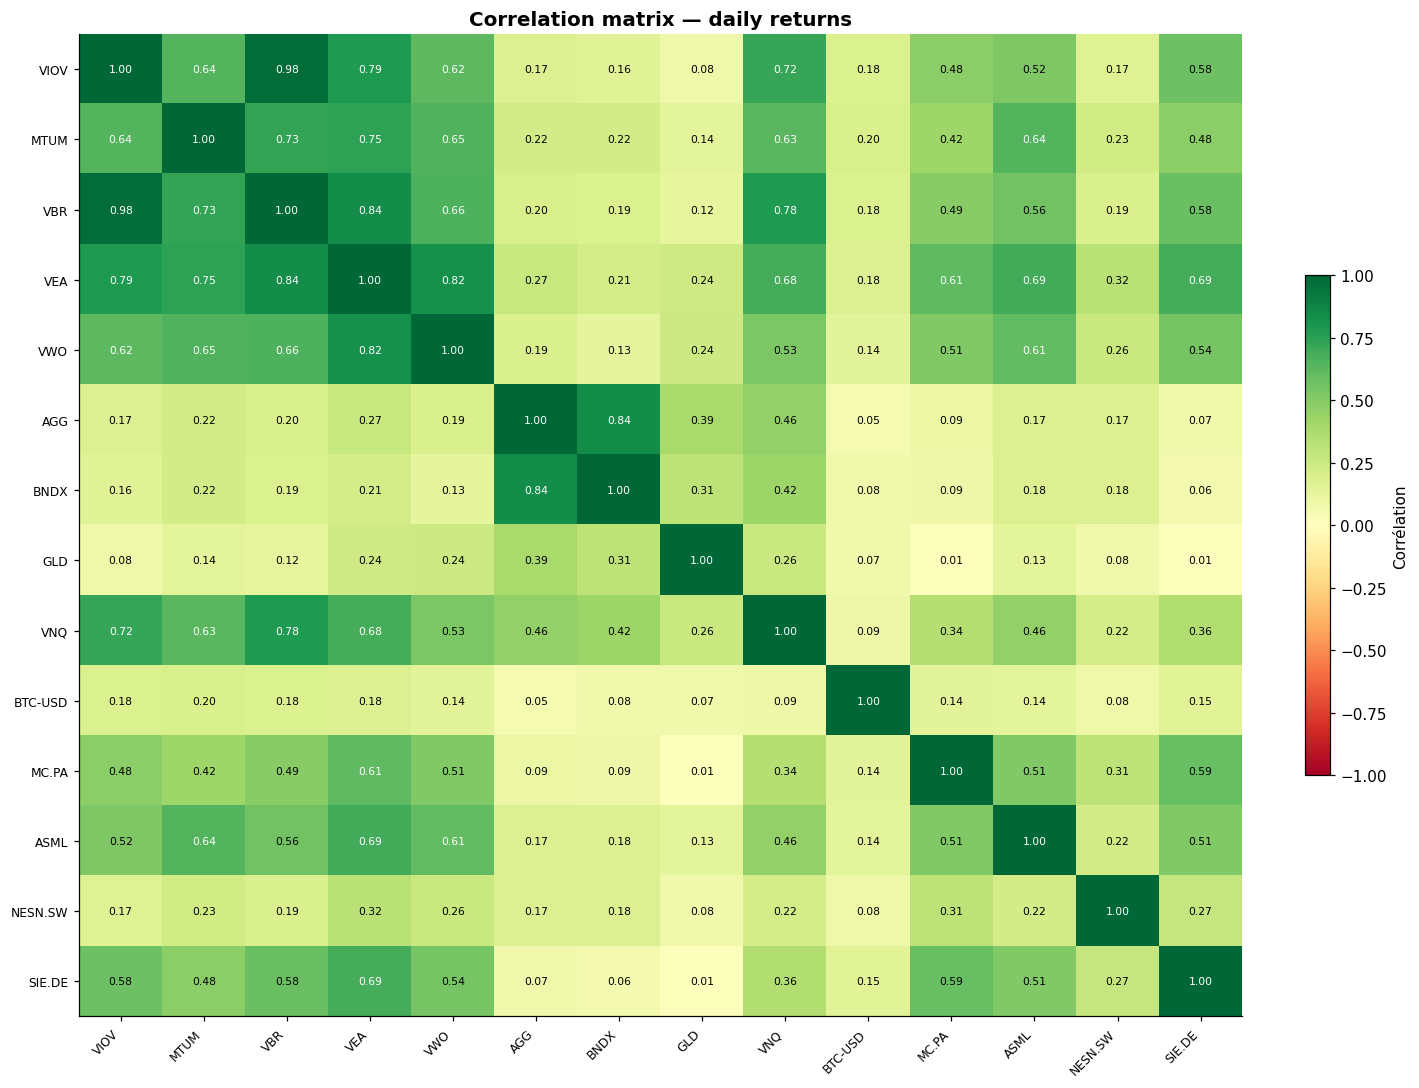

Average correlation per asset (listed in order of best diversifiers) :
Ticker
BTC-USD    0.193
GLD        0.220
NESN.SW    0.265
BNDX       0.290
AGG        0.307
MC.PA      0.399
SIE.DE     0.421
ASML       0.453
VWO        0.493
MTUM       0.497
VNQ        0.497
VIOV       0.507
VBR        0.535
VEA        0.577
dtype: float64


In [56]:
# Correlation matrix — daily returns
corr = weekly_returns.corr()
fig, ax = plt.subplots(figsize=(13, 10))
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(PORTFOLIO_TICKERS)))
ax.set_yticks(range(len(PORTFOLIO_TICKERS)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(corr.index, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.values[i, j]
        col = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7, color=col)
plt.colorbar(im, ax=ax, fraction=0.02, label='Corrélation')
ax.set_title('Correlation matrix — daily returns', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

# Diversifiers: assets with the lowest average correlation
corr_mean = corr.mean().sort_values()
print('Average correlation per asset (listed in order of best diversifiers) :')
print(corr_mean.round(3))

## 3. Instrument Selection

Each instrument must have at least **10 years of historical data** to support the backtest.

In [57]:
history = pd.DataFrame({
    'First date': prices.apply(lambda x: x.first_valid_index()),
    'Last date': prices.apply(lambda x: x.last_valid_index()),
})
history['Years'] = ((history['Last date'] - history['First date']).dt.days / 365.25).round(1)
history['✓ 10 years'] = history['Years'] >= 10
history = history.sort_values('Years', ascending=False)
print('=== Historical availability by asset ===\n')
print(history.to_string())
print(f"\n{history['✓ 10 years'].sum()}/{len(history)} assets meet the 10-year criterion.")


=== Historical availability by asset ===

        First date  Last date  Years  ✓ 10 years
Ticker                                          
VIOV    2014-09-21 2026-05-24   11.7        True
MTUM    2014-09-21 2026-05-24   11.7        True
VBR     2014-09-21 2026-05-24   11.7        True
VEA     2014-09-21 2026-05-24   11.7        True
VWO     2014-09-21 2026-05-24   11.7        True
AGG     2014-09-21 2026-05-24   11.7        True
BNDX    2014-09-21 2026-05-24   11.7        True
GLD     2014-09-21 2026-05-24   11.7        True
VNQ     2014-09-21 2026-05-24   11.7        True
BTC-USD 2014-09-21 2026-05-24   11.7        True
MC.PA   2014-09-21 2026-05-24   11.7        True
ASML    2014-09-21 2026-05-24   11.7        True
NESN.SW 2014-09-21 2026-05-24   11.7        True
SIE.DE  2014-09-21 2026-05-24   11.7        True

14/14 assets meet the 10-year criterion.


## 4. Portfolio Construction

### 4.1 Fixed-Mix — US Equity Sub-Portfolio & Portefeuille Global

In [58]:
# --- US Equity Sub-Portfolio (equal-weight fixed-mix) ---
US_SUB = ['VIOV', 'MTUM', 'VBR']
w_us_fixed = pd.Series({t: 1/3 for t in US_SUB}, name='US Equity Fixed-Mix')

# --- Portefeuille global diversifié (fixed-mix) ---
GLOBAL_FIXED = pd.Series({
    'VIOV': 0.10, 'MTUM': 0.10, 'VBR':     0.10,
    'VEA':  0.12, 'VWO':  0.08,
    'AGG':  0.15, 'BNDX': 0.10,
    'GLD':  0.07, 'VNQ':  0.05,
    'MC.PA':0.05, 'ASML': 0.04, 'NESN.SW': 0.02, 'SIE.DE': 0.02,
}, name='Global Fixed-Mix')

print('US Equity Sub-Portfolio :'); print(w_us_fixed.to_string())
print(f'Total : {w_us_fixed.sum():.0%}\n')
print('Global Diversified Portfolio :'); print(GLOBAL_FIXED.to_string())
print(f'Total : {GLOBAL_FIXED.sum():.0%}')


US Equity Sub-Portfolio :
VIOV    0.333333
MTUM    0.333333
VBR     0.333333
Total : 100%

Global Diversified Portfolio :
VIOV       0.10
MTUM       0.10
VBR        0.10
VEA        0.12
VWO        0.08
AGG        0.15
BNDX       0.10
GLD        0.07
VNQ        0.05
MC.PA      0.05
ASML       0.04
NESN.SW    0.02
SIE.DE     0.02
Total : 100%


### 4.2 Weight optimisation — FF3 & CAPM (Max Sharpe)

In [60]:
import requests, zipfile, io

def get_ff3_daily(start=START):
    """Download daily FF3 data from Kenneth French without pandas_datareader."""
    url = ("https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/"
           "ftp/F-F_Research_Data_Factors_daily_CSV.zip")
    r = requests.get(url, timeout=30)
    z = zipfile.ZipFile(io.BytesIO(r.content))
    fname = z.namelist()[0]
    
    # Read the CSV file, ignoring the text header rows
    df = pd.read_csv(z.open(fname), skiprows=4, index_col=0)
    
    # Keep only rows with a numeric index (YYYYMMDD format)
    df = df[df.index.astype(str).str.match(r'^\s*\d{8}\s*$')]
    df.index = pd.to_datetime(df.index.astype(str).str.strip(), format='%Y%m%d')
    df.columns = df.columns.str.strip()  # remove spaces from names
    df = df.astype(float) / 100          # % → decimal
    
    return df.loc[start:]

# ── 1. Download daily FF3 factors ────────────────────────────
ff3_daily = get_ff3_daily(start=START)
print(ff3_daily.head())
print(ff3_daily.columns.tolist())  # ['Mkt-RF', 'SMB', 'HML', 'RF']

# ── 2. Converting FF3 to a weekly rate (arithmetic compounding) ────────────
# Factors = arithmetic yields → Π(1 + r) - 1, no sum
# RF = risk-free rate → same, compounding
ff3_weekly = (1 + ff3_daily).resample('W').prod() - 1

# ── 3. Weekly market returns (VT) ─────────────────────────────
# Consistent with the weekly_prices already calculated above
mkt_weekly = np.log(weekly_prices['VT'] / weekly_prices['VT'].shift(1)).dropna()

# ── 4. Index cross-references — all on a weekly basis ─────────────
common_idx = (weekly_returns.index
              .intersection(ff3_weekly.index)
              .intersection(mkt_weekly.index))

R       = weekly_returns.loc[common_idx, PORTFOLIO_TICKERS]
F       = ff3_weekly.loc[common_idx]
rf_w    = F['RF']                          # RF weekly
factors = F[['Mkt-RF', 'SMB', 'HML']]

# Consistent annualisation: 52 weeks
rf_annual     = (1 + rf_w).prod() ** (52 / len(rf_w)) - 1   # annualised compound interest rate
factor_premia = (1 + factors).prod() ** (52 / len(factors)) - 1  # the same applies to premiums

# ── 5. FF3 regression on weekly data ────────────────────────────
betas_ff3  = {}
alphas_ff3 = {}
r2_ff3     = {}

for t in PORTFOLIO_TICKERS:
    excess = (R[t] - rf_w).values                              # weekly excess
    X      = np.column_stack([np.ones(len(factors)), factors.values])
    coeffs, _, _, _ = np.linalg.lstsq(X, excess, rcond=None)
    y_pred = X @ coeffs
    ss_res = np.sum((excess - y_pred) ** 2)
    ss_tot = np.sum((excess - excess.mean()) ** 2)

    # Annualised alpha: 52-week performance
    alphas_ff3[t] = (1 + coeffs[0]) ** 52 - 1
    betas_ff3[t]  = dict(zip(['Mkt-RF', 'SMB', 'HML'], coeffs[1:]))
    r2_ff3[t]     = 1 - ss_res / ss_tot

betas_df = pd.DataFrame(betas_ff3).T

# ── 6. Expected returns for FF3 ─────────────────────────────────────────────
mu_ff3 = pd.Series({
    t: rf_annual
       + betas_ff3[t]['Mkt-RF'] * factor_premia['Mkt-RF']
       + betas_ff3[t]['SMB']    * factor_premia['SMB']
       + betas_ff3[t]['HML']    * factor_premia['HML']
    for t in PORTFOLIO_TICKERS
}, name='E[r] FF3')

print(' FF3 annualized premiums (composed) :')
print(factor_premia.round(4))
print(f'\nrf annualized (composed) : {rf_annual:.4f}\n')
print('Expected returns FF3 :')
print(mu_ff3.sort_values(ascending=False).round(4))

            Mkt-RF     SMB     HML   RF
2013-01-02  0.0262  0.0013  0.0040  0.0
2013-01-03 -0.0013  0.0010  0.0005  0.0
2013-01-04  0.0055  0.0012  0.0037  0.0
2013-01-07 -0.0031 -0.0009 -0.0036  0.0
2013-01-08 -0.0026  0.0005 -0.0001  0.0
['Mkt-RF', 'SMB', 'HML', 'RF']
 FF3 annualized premiums (composed) :
Mkt-RF    0.0980
SMB      -0.0385
HML      -0.0070
dtype: float64

rf annualized (composed) : 0.0281

Expected returns FF3 :
ASML       0.1701
MTUM       0.1415
VNQ        0.1162
VBR        0.1063
VEA        0.1005
VIOV       0.0896
MC.PA      0.0882
VWO        0.0881
SIE.DE     0.0859
BTC-USD    0.0658
NESN.SW    0.0525
GLD        0.0411
AGG        0.0341
BNDX       0.0339
Name: E[r] FF3, dtype: float64


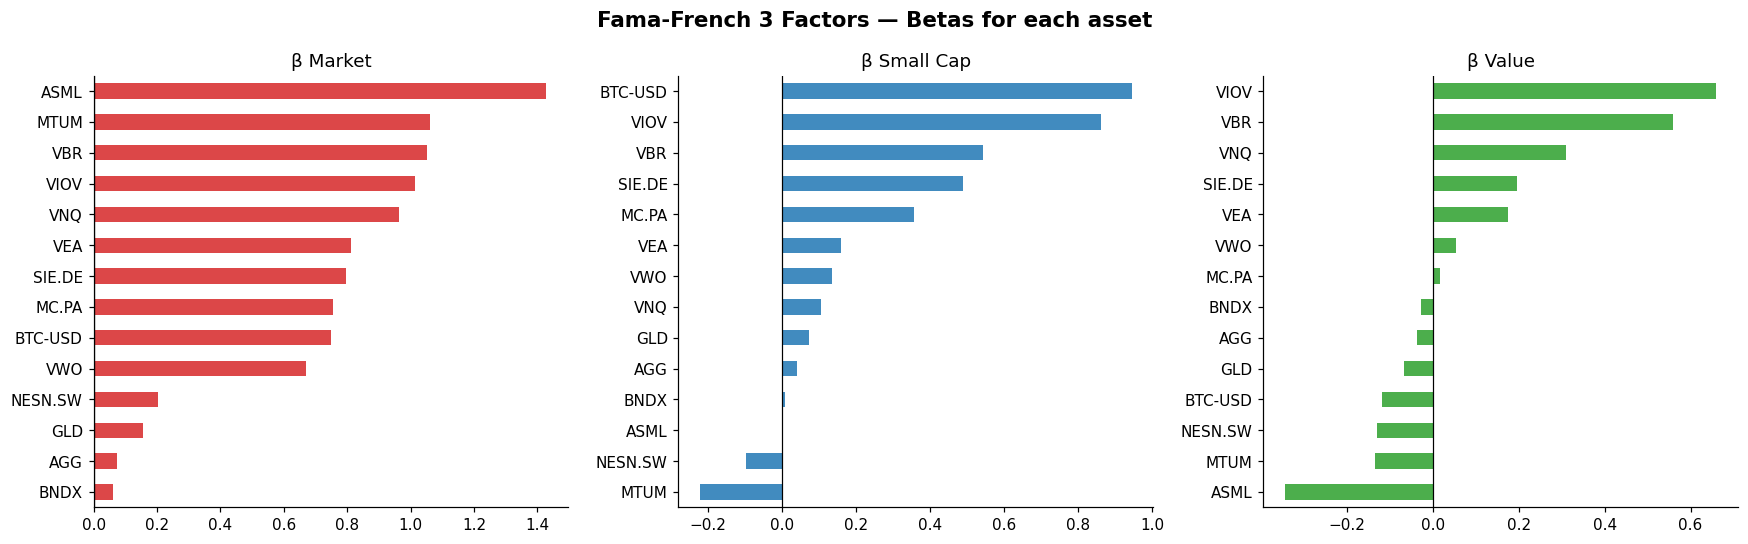

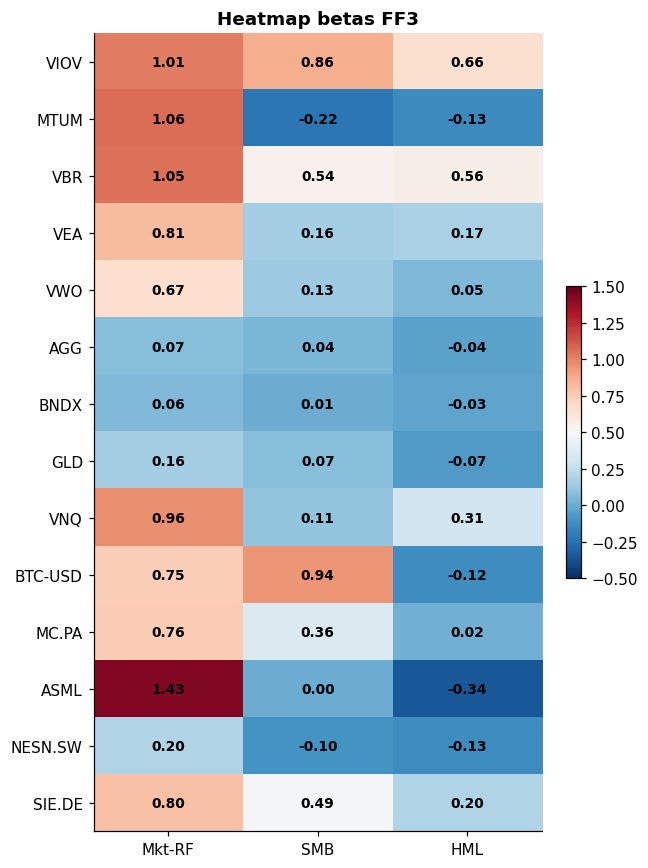

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Fama-French 3 Factors — Betas for each asset', fontsize=14, fontweight='bold')
factor_meta = [('Mkt-RF','#d62728','β Market'),('SMB','#1f77b4','β Small Cap'),('HML','#2ca02c','β Value')]
for ax, (factor, color, label) in zip(axes, factor_meta):
    betas_df[factor].sort_values().plot(kind='barh', ax=ax, color=color, alpha=0.85)
    ax.axvline(0, color='black', lw=0.8); ax.set_title(label)
plt.tight_layout(); plt.show()
fig, ax = plt.subplots(figsize=(6, 8))
im = ax.imshow(betas_df.values, cmap='RdBu_r', aspect='auto', vmin=-0.5, vmax=1.5)
ax.set_xticks(range(3)); ax.set_xticklabels(['Mkt-RF','SMB','HML'])
ax.set_yticks(range(len(PORTFOLIO_TICKERS))); ax.set_yticklabels(betas_df.index)
for i in range(len(PORTFOLIO_TICKERS)):
    for j in range(3):
        ax.text(j, i, f'{betas_df.values[i,j]:.2f}', ha='center', va='center', fontsize=9, fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.03)
ax.set_title('Heatmap betas FF3', fontweight='bold')
plt.tight_layout(); plt.show()

In [62]:
mkt_weekly
mkt_aligned = mkt_weekly.loc[common_idx]
betas_capm = {}; alphas_capm = {}; r2_capm = {}
for t in PORTFOLIO_TICKERS:
    excess_i   = R[t] - rf_w
    excess_mkt = mkt_aligned - rf_w
    slope, intercept, r_val, _, _ = sp_stats.linregress(excess_mkt, excess_i)
    betas_capm[t] = slope; alphas_capm[t] = intercept*52  # weekly → annuel; 
    r2_capm[t] = r_val**2
mkt_premium = (mkt_aligned - rf_w).mean() * 52
mu_capm = pd.Series({
    t: rf_annual + betas_capm[t]*mkt_premium for t in PORTFOLIO_TICKERS}, name='E[r] CAPM')
print(f'Market premium (VT) : {mkt_premium:.4f}')
print(pd.concat([pd.Series(betas_capm,name='Beta'),pd.Series(r2_capm,name='R2')],axis=1).round(3))

Market premium (VT) : 0.0757
          Beta     R2
VIOV     1.231  0.711
MTUM     1.067  0.759
VBR      1.223  0.807
VEA      0.974  0.894
VWO      0.826  0.677
AGG      0.099  0.096
BNDX     0.070  0.082
GLD      0.230  0.069
VNQ      1.063  0.624
BTC-USD  0.942  0.078
MC.PA    0.945  0.337
ASML     1.571  0.542
NESN.SW  0.227  0.055
SIE.DE   1.027  0.398


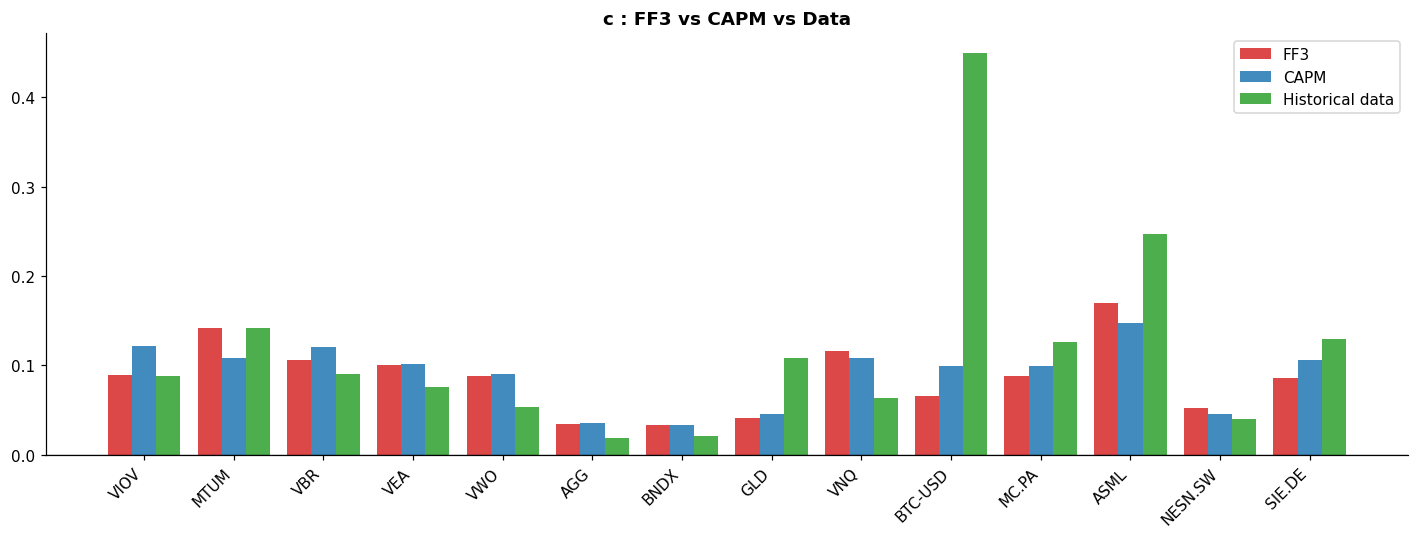

In [63]:
mu_compare = pd.DataFrame({'FF3':mu_ff3,'CAPM':mu_capm,'Historical data':ann_ret.loc[PORTFOLIO_TICKERS]})
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(PORTFOLIO_TICKERS)); width = 0.27
ax.bar(x-width, mu_compare['FF3'],        width, label='FF3',        color='#d62728', alpha=0.85)
ax.bar(x,       mu_compare['CAPM'],       width, label='CAPM',       color='#1f77b4', alpha=0.85)
ax.bar(x+width, mu_compare['Historical data'], width, label='Historical data', color='#2ca02c', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(PORTFOLIO_TICKERS, rotation=45, ha='right')
ax.set_title('c : FF3 vs CAPM vs Data', fontweight='bold')
ax.axhline(0, color='black', lw=0.8); ax.legend()
plt.tight_layout(); plt.show()

In [64]:
cov = R.cov() * 52
n   = len(PORTFOLIO_TICKERS)
def portfolio_metrics(w, mu, cov, rf):
    ret=w@mu; vol=np.sqrt(w@cov@w); sr=(ret-rf)/vol
    return ret, vol, sr
def neg_sharpe(w, mu, cov, rf): return -portfolio_metrics(w,mu,cov,rf)[2]
constraints = [{'type':'eq','fun':lambda w: w.sum()-1}]
bounds = [(0.0,0.40)]*n; w0 = np.ones(n)/n
opts   = {'ftol':1e-12,'maxiter':2000}
res_ff3  = minimize(neg_sharpe, w0, args=(mu_ff3.values,cov.values,rf_annual),
                    method='SLSQP',bounds=bounds,constraints=constraints,options=opts)
w_ff3 = pd.Series(res_ff3.x, index=PORTFOLIO_TICKERS)
res_capm = minimize(neg_sharpe, w0, args=(mu_capm.values,cov.values,rf_annual),
                    method='SLSQP',bounds=bounds,constraints=constraints,options=opts)
w_capm = pd.Series(res_capm.x, index=PORTFOLIO_TICKERS)
w_ew   = pd.Series(np.ones(n)/n, index=PORTFOLIO_TICKERS)
def fmt_m(w,mu,label):
    r,v,s=portfolio_metrics(w.values,mu.values,cov.values,rf_annual)
    return pd.Series({'Expected Return':r,'Volatility':v,'Sharpe':s},name=label)
summary=pd.concat([fmt_m(w_ff3,mu_ff3,'FF3'),fmt_m(w_capm,mu_capm,'CAPM'),fmt_m(w_ew,mu_ff3,'EW')],axis=1)
print('=== Best portfolios annualized indicators (ex-ante) ===\n'); print(summary.round(4))

=== Best portfolios annualized indicators (ex-ante) ===

                    FF3    CAPM      EW
Expected Return  0.0908  0.1069  0.0867
Volatility       0.1236  0.1898  0.1600
Sharpe           0.5074  0.4151  0.3663


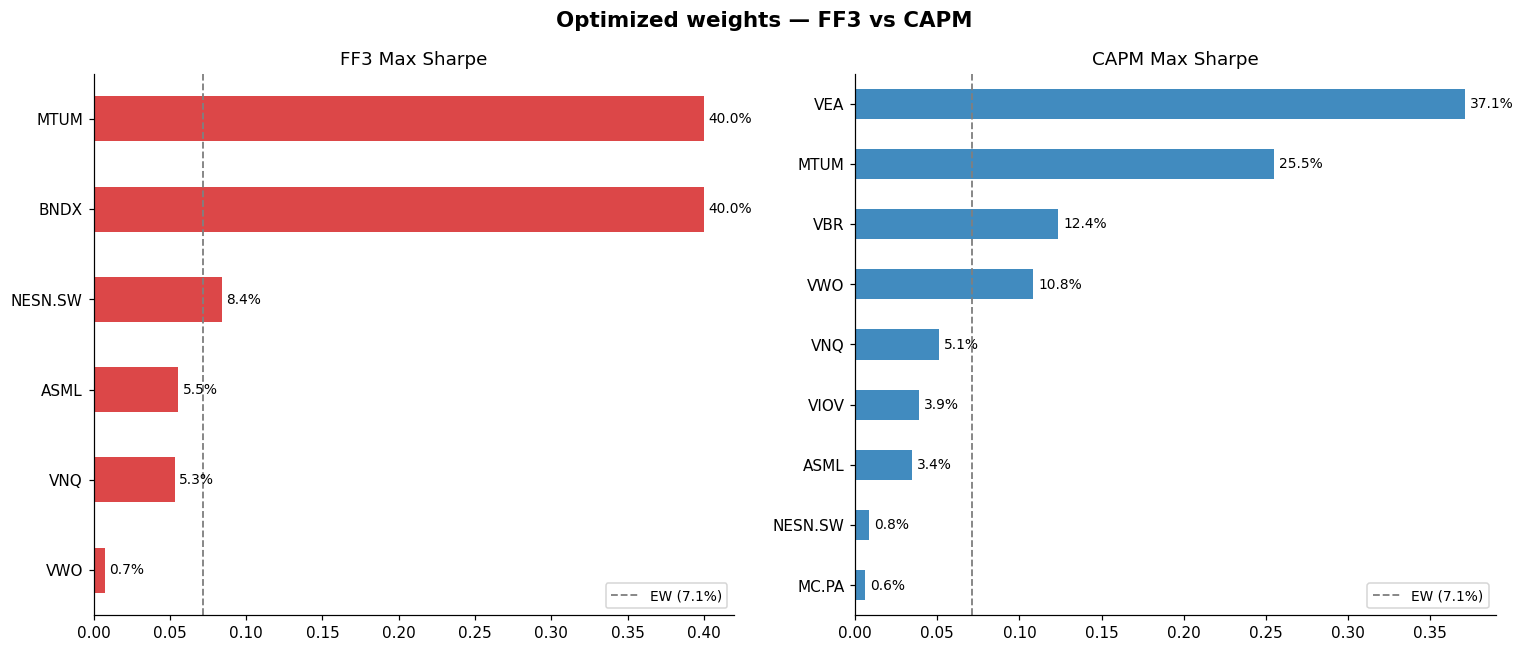

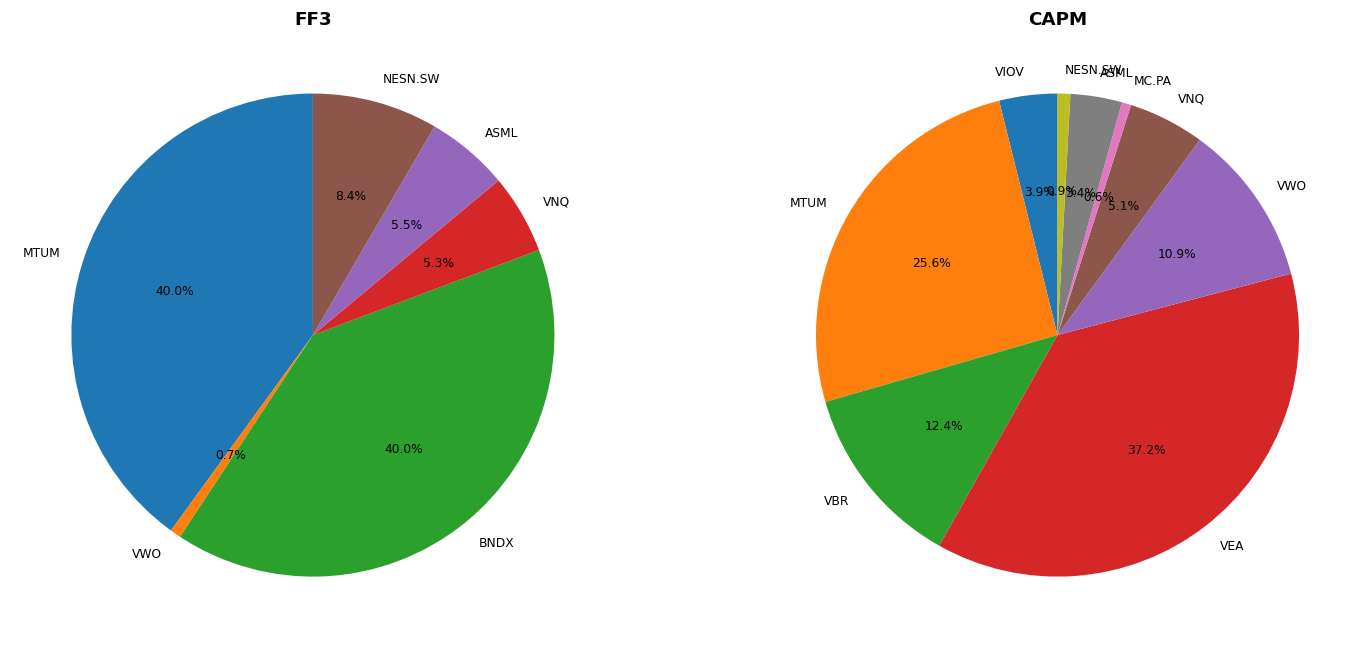

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Optimized weights — FF3 vs CAPM', fontsize=14, fontweight='bold')
for ax, (weights, model, color) in zip(axes,[
    (w_ff3,'FF3 Max Sharpe','#d62728'),(w_capm,'CAPM Max Sharpe','#1f77b4')]):
    w_plot = weights[weights>0.005].sort_values(ascending=True)
    w_plot.plot(kind='barh', ax=ax, color=color, alpha=0.85)
    ax.axvline(1/n, color='grey', linestyle='--', lw=1.2, label=f'EW ({1/n:.1%})')
    for i, val in enumerate(w_plot): ax.text(val+0.003,i,f'{val:.1%}',va='center',fontsize=9)
    ax.set_title(model); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax,(weights,model) in zip(axes,[(w_ff3,'FF3'),(w_capm,'CAPM')]):
    w_plot=weights[weights>0.005]
    ax.pie(w_plot,labels=w_plot.index,autopct='%1.1f%%',startangle=90,textprops={'fontsize':8})
    ax.set_title(model,fontweight='bold')
plt.tight_layout(); plt.show()

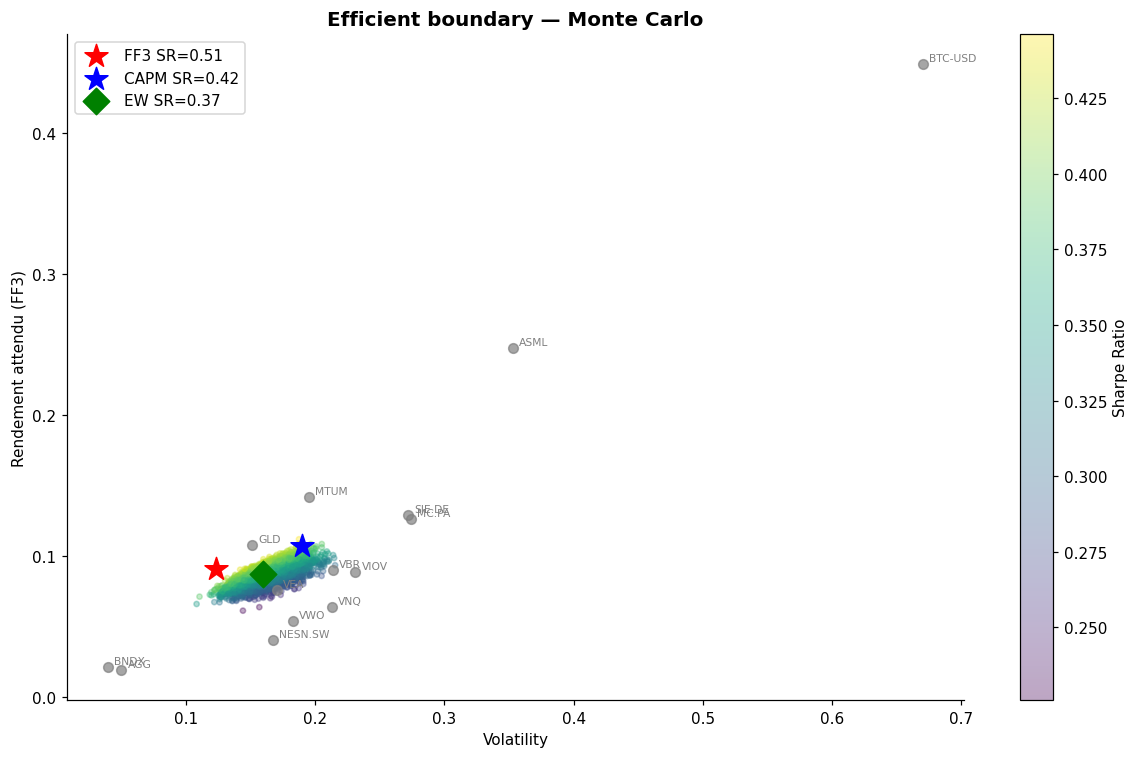

In [66]:
N_SIM=6000; sim_ret=np.zeros(N_SIM); sim_vol=np.zeros(N_SIM); sim_sr=np.zeros(N_SIM)
rng=np.random.default_rng(42)
for i in range(N_SIM):
    w=rng.random(n); w/=w.sum()
    r,v,s=portfolio_metrics(w,mu_ff3.values,cov.values,rf_annual)
    sim_ret[i]=r; sim_vol[i]=v; sim_sr[i]=s
r_ff3,v_ff3,s_ff3=portfolio_metrics(w_ff3.values,mu_ff3.values,cov.values,rf_annual)
r_capm,v_capm,s_capm=portfolio_metrics(w_capm.values,mu_capm.values,cov.values,rf_annual)
r_ew,v_ew,s_ew=portfolio_metrics(w_ew.values,mu_ff3.values,cov.values,rf_annual)
fig,ax=plt.subplots(figsize=(11,7))
sc=ax.scatter(sim_vol,sim_ret,c=sim_sr,cmap='viridis',alpha=0.35,s=12)
plt.colorbar(sc,ax=ax,label='Sharpe Ratio')
for t in PORTFOLIO_TICKERS:
    ax.scatter(ann_vol[t],ann_ret[t],s=40,color='grey',zorder=4,alpha=0.7)
    ax.annotate(t,(ann_vol[t],ann_ret[t]),fontsize=7,color='grey',textcoords='offset points',xytext=(4,2))
ax.scatter(v_ff3,r_ff3,s=250,color='red',zorder=6,marker='*',label=f'FF3 SR={s_ff3:.2f}')
ax.scatter(v_capm,r_capm,s=250,color='blue',zorder=6,marker='*',label=f'CAPM SR={s_capm:.2f}')
ax.scatter(v_ew,r_ew,s=150,color='green',zorder=6,marker='D',label=f'EW SR={s_ew:.2f}')
ax.set_xlabel('Volatility'); ax.set_ylabel('Rendement attendu (FF3)')
ax.set_title('Efficient boundary — Monte Carlo',fontweight='bold',fontsize=13)
ax.legend(fontsize=10); plt.tight_layout(); plt.show()

## 5. Benchmark Construction

Benchmark par défaut : **60% VT** (actions mondiales) **+ 40% AGG** (obligations US).

=== Portfolio 1 Benchmark VT 60% + AGG 40% ===
Annualized Returns  : 7.02%
Annualized Volatility : 11.72%
Sharpe Ratio         : 0.359
Max Drawdown         : -22.41%


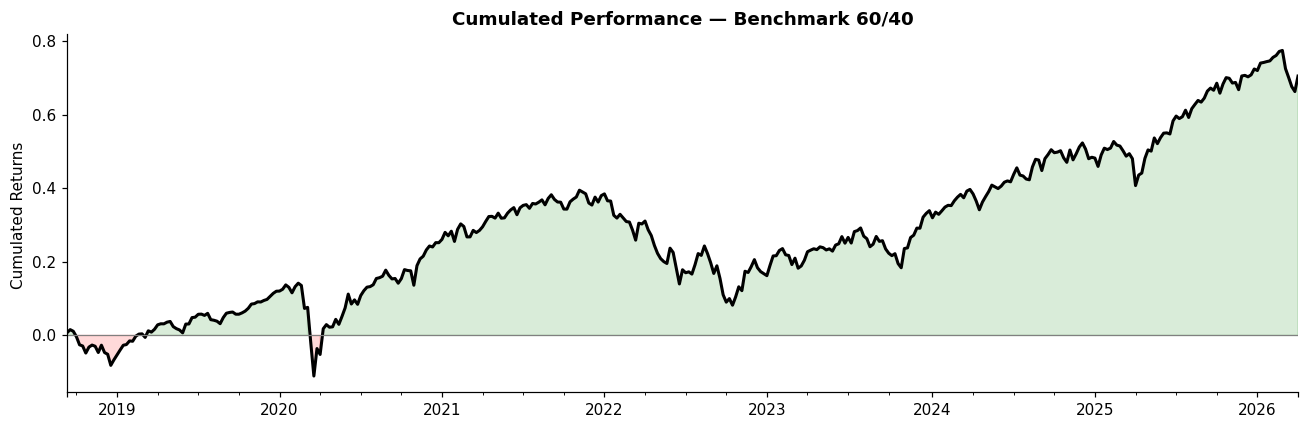

In [67]:
bench_w = pd.Series({'VT': 0.60, 'AGG': 0.40})
# Resample to weekly data BEFORE calculating returns (frequency alignment fix)
bench_prices_raw = raw[['VT','AGG']].ffill().dropna()
bench_prices_weekly = bench_prices_raw.resample('W').last()  # Clôture vendredi
bench_returns = np.log(bench_prices_weekly / bench_prices_weekly.shift(1)).dropna()
bench_6040_raw = (bench_returns * bench_w).sum(axis=1)
bench_6040 = bench_6040_raw.reindex(common_idx).dropna()  # Alignment now consistent ✓
bench_6040.name = '60/40 Benchmark'

cum_b   = np.exp(bench_6040.cumsum()) - 1
ret_b   = bench_6040.mean() * 52  # weekly → annual
vol_b   = bench_6040.std()  * np.sqrt(52)
sr_b    = (ret_b - rf_annual) / vol_b
dd_b    = (np.exp(bench_6040.cumsum()) / np.exp(bench_6040.cumsum()).cummax() - 1).min()

print('=== Portfolio 1 Benchmark VT 60% + AGG 40% ===')
print(f'Annualized Returns  : {ret_b:.2%}')
print(f'Annualized Volatility : {vol_b:.2%}')
print(f'Sharpe Ratio         : {sr_b:.3f}')
print(f'Max Drawdown         : {dd_b:.2%}')

fig, ax = plt.subplots(figsize=(12, 4))
cum_b.plot(ax=ax, color='black', lw=2)
ax.fill_between(cum_b.index, 0, cum_b, where=cum_b>=0, alpha=0.15, color='green')
ax.fill_between(cum_b.index, 0, cum_b, where=cum_b<0,  alpha=0.15, color='red')
ax.set_title('Cumulated Performance — Benchmark 60/40', fontweight='bold')
ax.set_ylabel('Cumulated Returns '); ax.axhline(0, color='grey', lw=0.8)
plt.tight_layout(); plt.show()

## 6. Factor Regression — FF6 (FF5 + Momentum)

Regression on the **US Equity sub-portfolio** (VIOV, MTUM, VBR) using 6 factors:

$$r_i - r_f = \alpha + \beta_{\text{mkt}}\cdot MKT + \beta_{\text{smb}}\cdot SMB + \beta_{\text{hml}}\cdot HML + \beta_{\text{rmw}}\cdot RMW + \beta_{\text{cma}}\cdot CMA + \beta_{\text{mom}}\cdot MOM + \varepsilon$$

In [68]:
def get_ff_factor(url, factor_col_name=None, start=START):
    """Download Fama-French factor data directly from Kenneth French's website."""
    r = requests.get(url, timeout=30)
    z = zipfile.ZipFile(io.BytesIO(r.content))
    fname = z.namelist()[0]
    
    # Read all lines to find header + data start
    with z.open(fname) as f:
        lines = f.read().decode('utf-8', errors='ignore').splitlines()
    
    # Find the first data line (YYYYMMDD) → header is one line above
    header_row = 0
    for i, line in enumerate(lines):
        stripped = line.strip().replace(' ', '').replace(',', '')
        if stripped[:8].isdigit() and len(stripped) >= 8:
            header_row = i - 1  # ← ligne des noms de colonnes = juste avant
            break
    
    print(f"  → Header at line {header_row}: {lines[header_row]}")
    print(f"  → First data line {header_row+1}: {lines[header_row+1]}")
    
    # Re-read with correct skiprows
    with z.open(fname) as f:
        df = pd.read_csv(f, skiprows=header_row, index_col=0)
    
    # Keep only rows with valid YYYYMMDD index
    df = df[df.index.astype(str).str.match(r'^\s*\d{8}\s*$')]
    df.index = pd.to_datetime(df.index.astype(str).str.strip(), format='%Y%m%d')
    df.columns = df.columns.str.strip()
    df = df.astype(float) / 100
    
    # Rename if needed (e.g. Mom column)
    if factor_col_name:
        df = df.rename(columns={df.columns[0]: factor_col_name})
    
    print(f"  → Columns: {df.columns.tolist()}")
    print(f"  → Shape: {df.shape}\n")
    
    return df.loc[start:]

# Test
ff5 = get_ff_factor(
    url="https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/"
        "ftp/F-F_Research_Data_5_Factors_2x3_daily_CSV.zip",
    start=START
)

mom = get_ff_factor(
    url="https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/"
        "ftp/F-F_Momentum_Factor_daily_CSV.zip",
    factor_col_name='Mom',
    start=START
)


# ── 3. Merge FF6 = FF5 + Momentum (daily, then resample weekly) ─────────────
FACTORS_FF6   = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'Mom']

ff6_all_daily = ff5[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']].join(
    mom[['Mom']], how='inner'
)

print(f"FF6 daily shape : {ff6_all_daily.shape}")
print(f"Date range      : {ff6_all_daily.index[0].date()} → {ff6_all_daily.index[-1].date()}")
print(ff6_all_daily.head(3))

# Resample to weekly via geometric compounding
ff6_all = (1 + ff6_all_daily).resample('W').prod() - 1

print(f"\nFF6 weekly shape: {ff6_all.shape}")
print(ff6_all.head(3))

# ── 4. Align with US Equity sub-portfolio ───────────────────────────────────
us_common = R[US_SUB].index.intersection(ff6_all.index)
R_us      = R.loc[us_common, US_SUB]
ff6_al    = ff6_all.loc[us_common]
rf_us     = F.loc[us_common, 'RF']

print(f"Common observations: {len(us_common)}")
print(f"Assets in US_SUB   : {US_SUB}")

# ── 5. FF6 regression ───────────────────────────────────────────────────────
betas_ff6  = {}
alphas_ff6 = {}
tstats_ff6 = {}
r2_ff6     = {}

for t in US_SUB:
    excess = (R_us[t] - rf_us).values
    X      = np.column_stack([np.ones(len(ff6_al)), ff6_al[FACTORS_FF6].values])
    n, k   = X.shape

    coeffs, _, _, _ = np.linalg.lstsq(X, excess, rcond=None)
    y_pred  = X @ coeffs
    resid   = excess - y_pred
    ss_res  = np.sum(resid ** 2)
    ss_tot  = np.sum((excess - excess.mean()) ** 2)

    # Standard errors → t-stats
    sigma2  = ss_res / (n - k)
    cov_mat = sigma2 * np.linalg.inv(X.T @ X)
    se      = np.sqrt(np.diag(cov_mat))
    tstat   = coeffs / se

    alphas_ff6[t] = coeffs[0] * 52          # annualised weekly alpha
    betas_ff6[t]  = dict(zip(FACTORS_FF6, coeffs[1:]))
    tstats_ff6[t] = dict(zip(['alpha'] + FACTORS_FF6, tstat))
    r2_ff6[t]     = 1 - ss_res / ss_tot

# ── 6. Results ───────────────────────────────────────────────────────────────
betas_ff6_df  = pd.DataFrame(betas_ff6).T
tstats_ff6_df = pd.DataFrame(tstats_ff6).T

print('\n' + '=' * 60)
print('FF6 Regression — US Equity Sub-Portfolio')
print('=' * 60)

print('\nFactor Betas:')
print(betas_ff6_df.round(4))

print('\nt-statistics:')
print(tstats_ff6_df.round(3))

print('\nAnnualised Alphas:')
for t, a in alphas_ff6.items():
    stars = '***' if abs(tstats_ff6[t]['alpha']) > 2.576 else \
            '**'  if abs(tstats_ff6[t]['alpha']) > 1.96  else \
            '*'   if abs(tstats_ff6[t]['alpha']) > 1.645 else ''
    print(f"  {t:<10} α = {a:.4f}  (t = {tstats_ff6[t]['alpha']:.3f}) {stars}")

print('\nR-Squared:')
for t, r2 in r2_ff6.items():
    print(f"  {t:<10} R² = {r2:.4f}")

  → Header at line 4: ,Mkt-RF,SMB,HML,RMW,CMA,RF
  → First data line 5: 19630701,   -0.67,    0.00,   -0.34,   -0.01,    0.16,    0.01
  → Columns: ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
  → Shape: (15792, 6)

  → Header at line 13: ,Mom
  → First data line 14: 19261103,   0.54
  → Columns: ['Mom']
  → Shape: (26111, 1)

FF6 daily shape : (3331, 6)
Date range      : 2013-01-02 → 2026-03-31
            Mkt-RF     SMB     HML     RMW     CMA     Mom
2013-01-02  0.0262  0.0010  0.0040 -0.0067 -0.0001  0.0020
2013-01-03 -0.0013  0.0014  0.0005  0.0022  0.0024 -0.0044
2013-01-04  0.0055  0.0019  0.0037 -0.0036  0.0024 -0.0038

FF6 weekly shape: (692, 6)
              Mkt-RF       SMB       HML       RMW       CMA       Mom
2013-01-06  0.030503  0.004306  0.008219 -0.008098  0.004705 -0.006200
2013-01-13  0.004474 -0.003714 -0.007012 -0.003201 -0.003997  0.007085
2013-01-20  0.009420  0.005098 -0.000404  0.001898  0.006612 -0.004501
Common observations: 395
Assets in US_SUB   : ['VIOV'

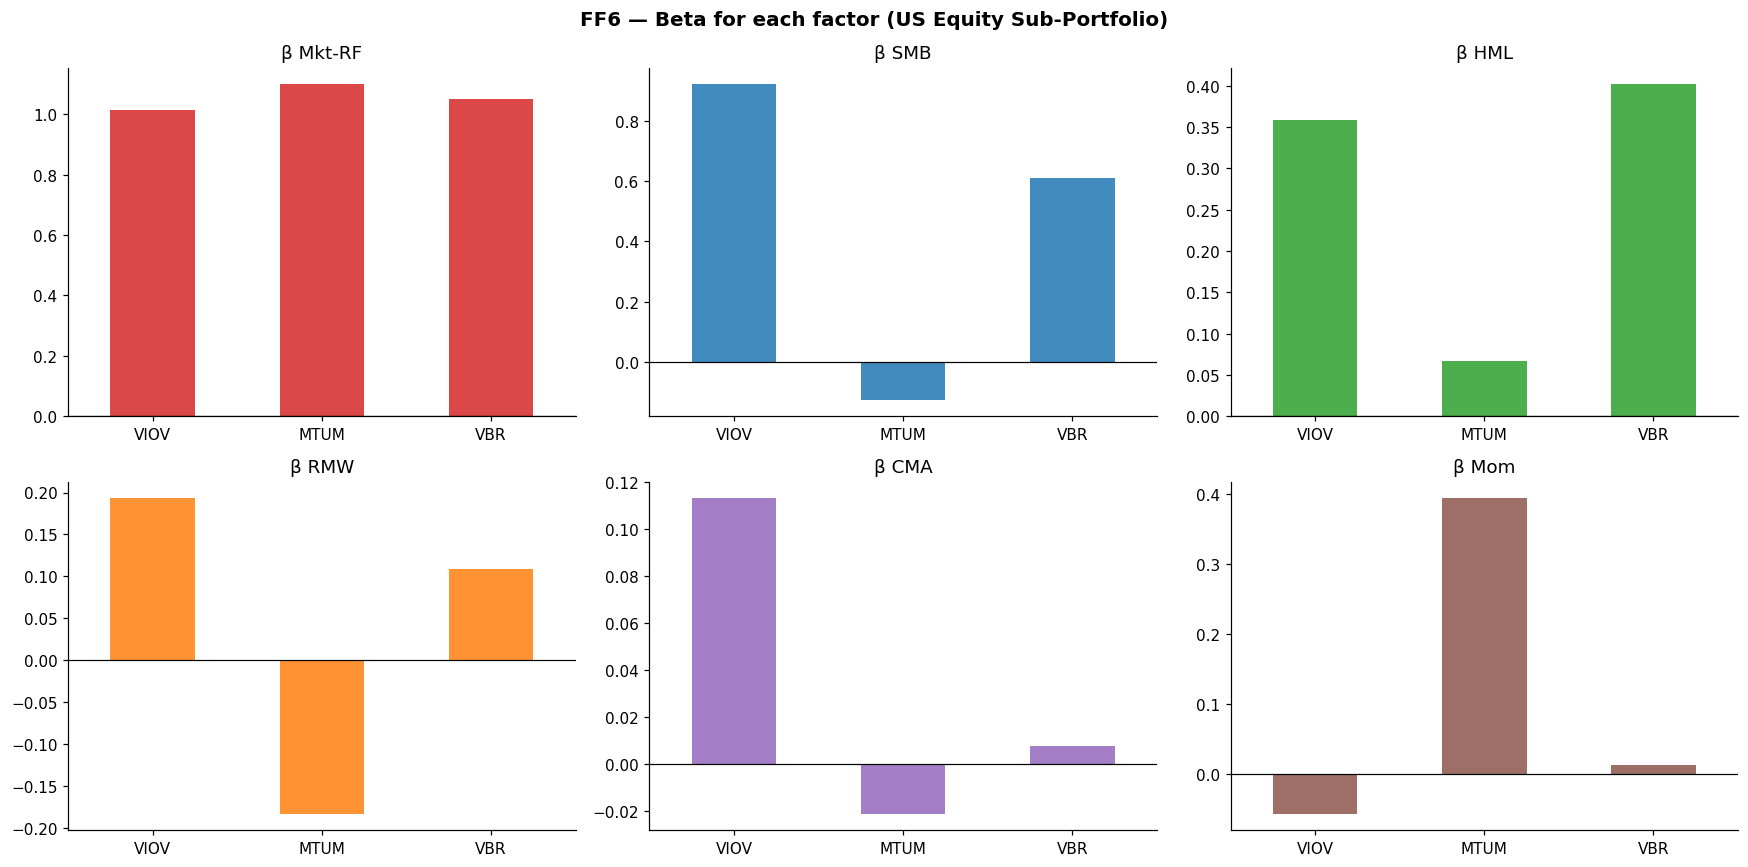

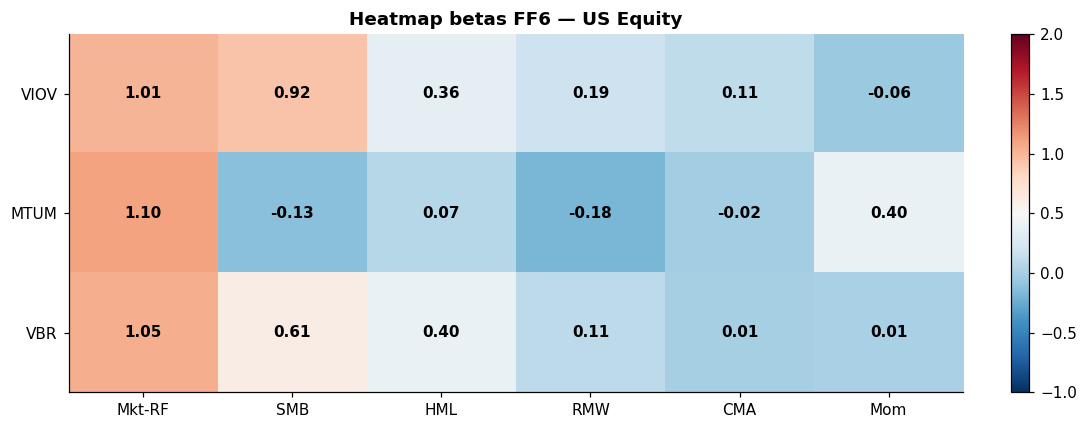

In [69]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('FF6 — Beta for each factor (US Equity Sub-Portfolio)', fontsize=13, fontweight='bold')
f_colors = ['#d62728','#1f77b4','#2ca02c','#ff7f0e','#9467bd','#8c564b']
for ax,(factor,color) in zip(axes.flatten(), zip(FACTORS_FF6, f_colors)):
    betas_ff6_df[factor].plot(kind='bar', ax=ax, color=color, alpha=0.85)
    ax.axhline(0, color='black', lw=0.8); ax.set_title(f'β {factor}')
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

# Heatmap FF6
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(betas_ff6_df.values, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=2)
ax.set_xticks(range(6)); ax.set_xticklabels(FACTORS_FF6)
ax.set_yticks(range(len(US_SUB))); ax.set_yticklabels(US_SUB)
for i in range(len(US_SUB)):
    for j in range(6):
        ax.text(j, i, f'{betas_ff6_df.values[i,j]:.2f}', ha='center', va='center', fontsize=10, fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.02)
ax.set_title('Heatmap betas FF6 — US Equity', fontweight='bold')
plt.tight_layout(); plt.show()

## 7. Backtest & Performance Analysis

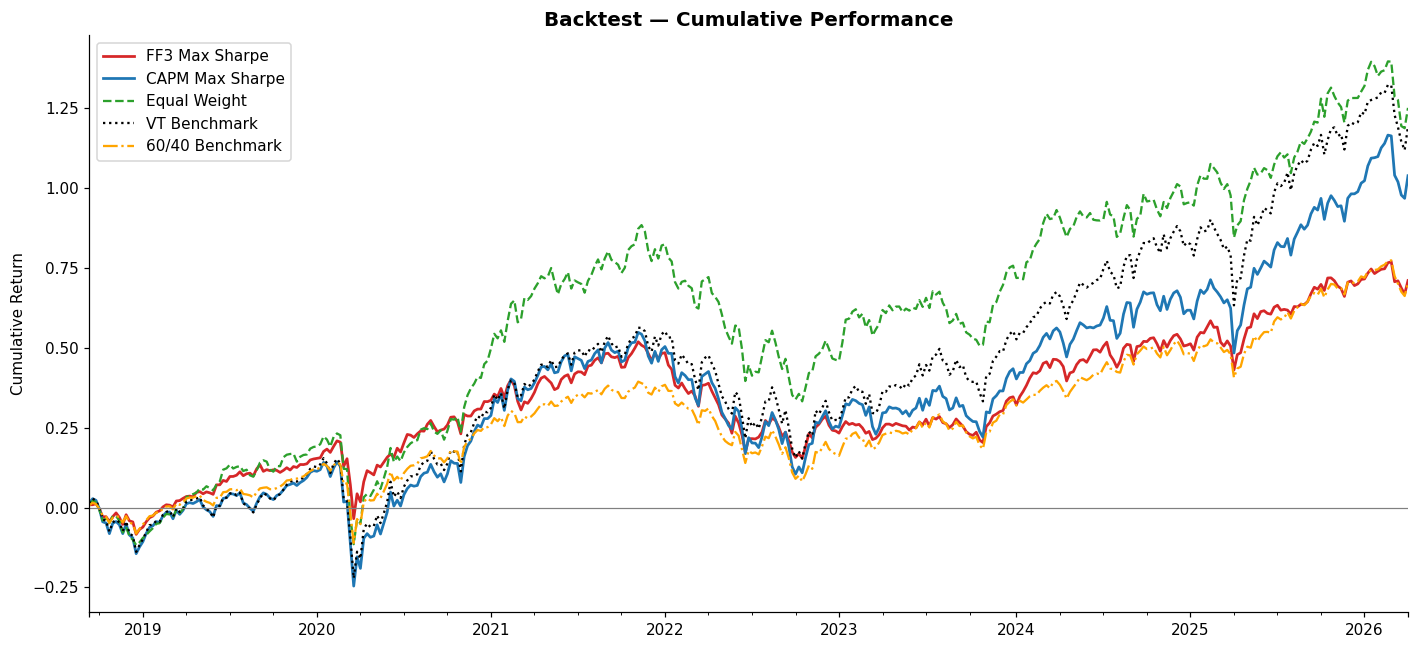

=== Ex-Post Performance Metrics ===

                       FF3 Max Sharpe  CAPM Max Sharpe  Equal Weight  \
Annualized Return              0.0707           0.0938        0.1068   
Annualized Volatility          0.1236           0.1898        0.1600   
Sharpe Ratio                   0.3445           0.3461        0.4922   
Sortino Ratio                  0.4390           0.4203        0.6026   
Max Drawdown                  -0.2399          -0.3401       -0.2928   
Calmar Ratio                   0.2946           0.2758        0.3649   
VaR 95% (weekly)              -0.0245          -0.0374       -0.0319   
CVaR 95% (weekly)             -0.0402          -0.0629       -0.0523   
Hit Rate                       0.5747           0.5570        0.5797   

                       VT Benchmark  60/40 Benchmark  
Annualized Return            0.1034           0.0702  
Annualized Volatility        0.1800           0.1172  
Sharpe Ratio                 0.4185           0.3593  
Sortino Ratio         

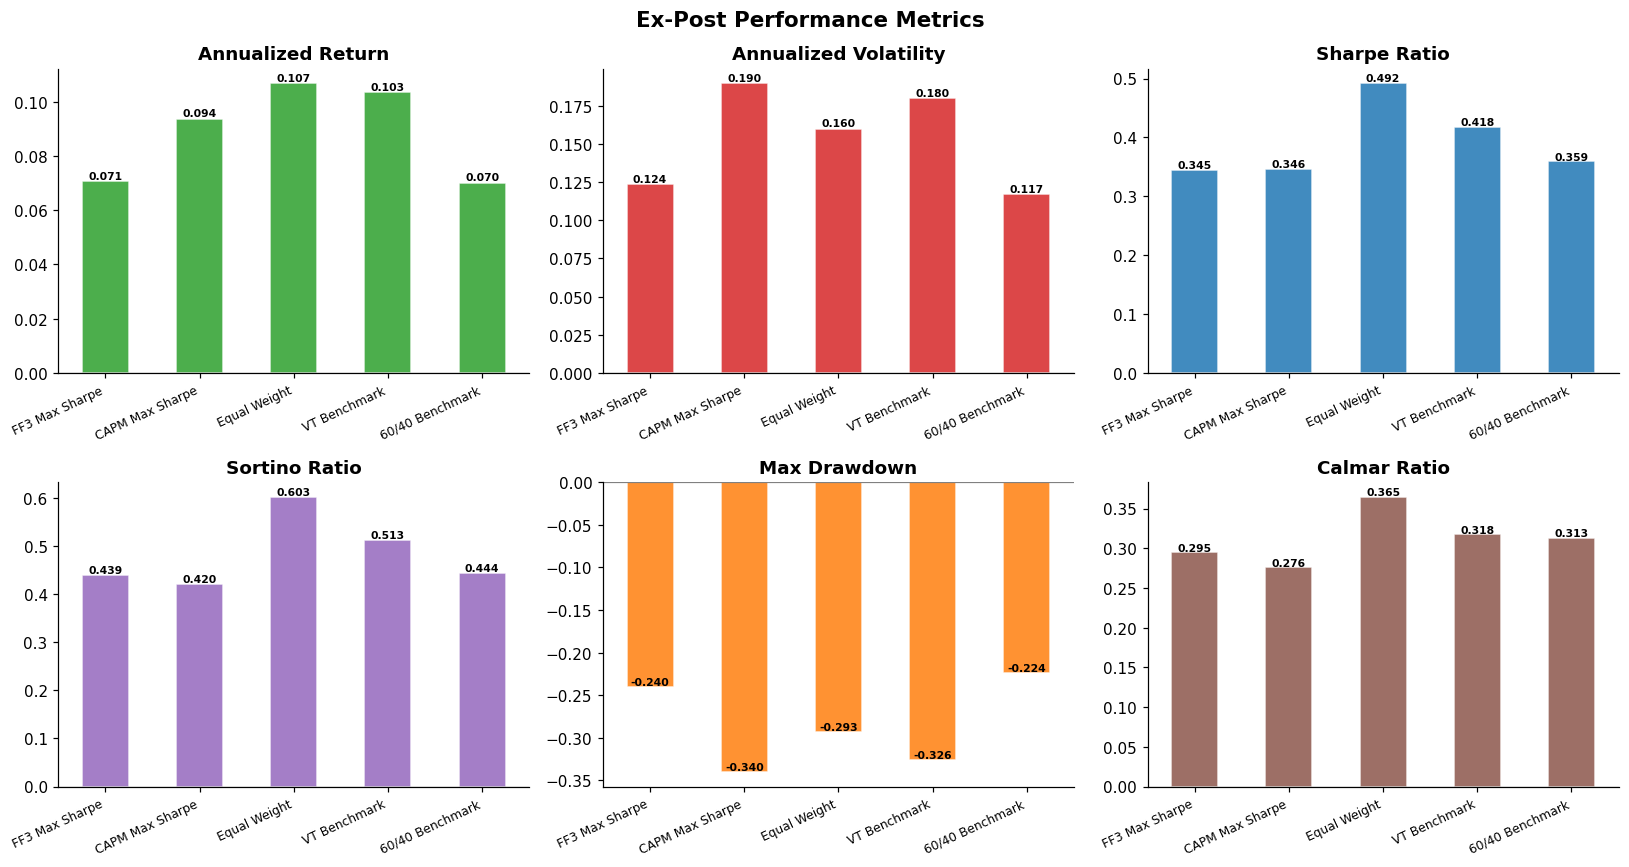

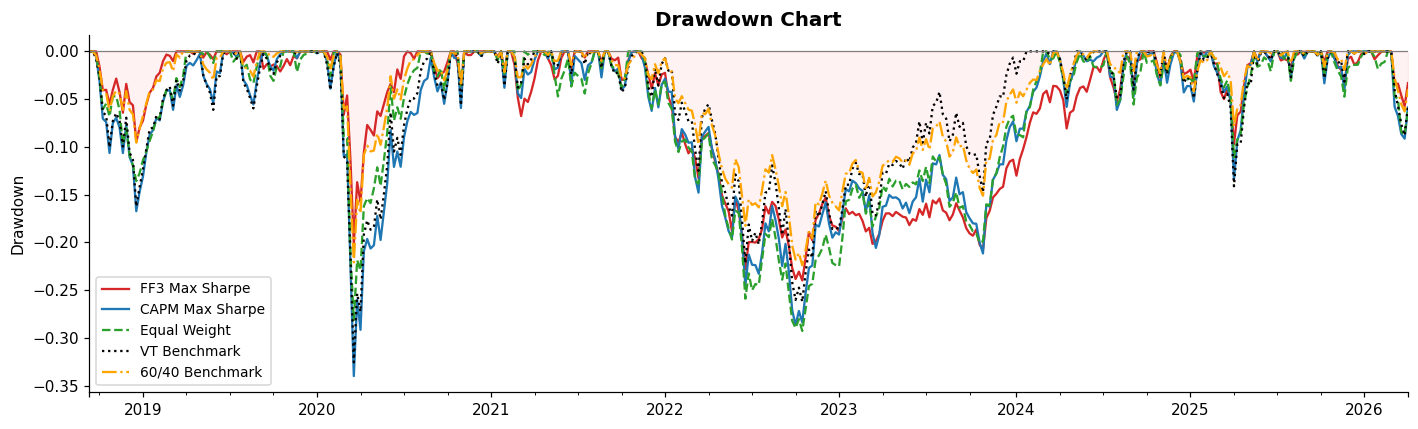

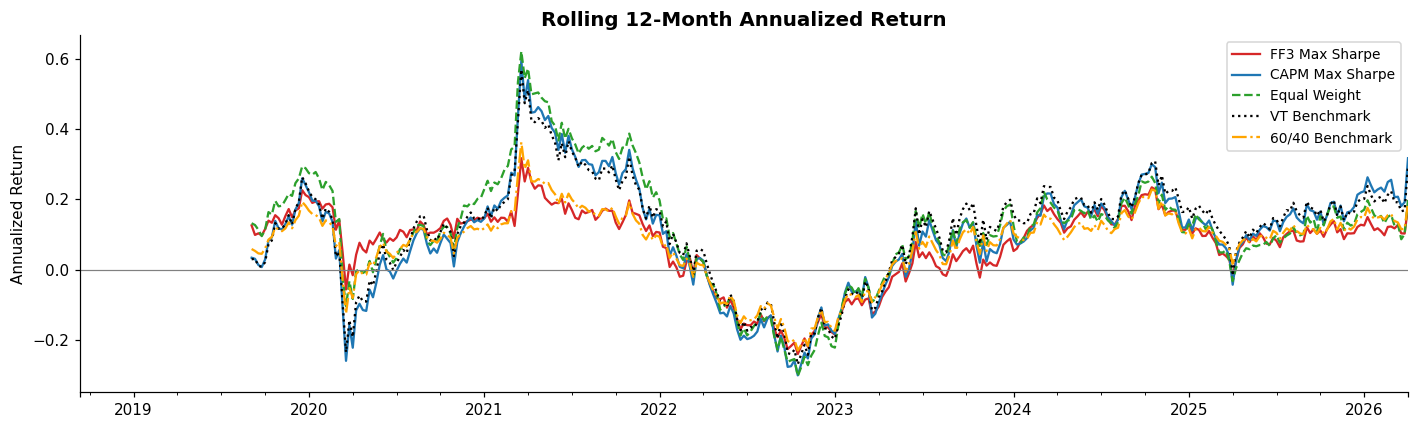

In [70]:
# ── 1. Portfolio returns ─────────────────────────────────────────────────────
port_ff3  = (R * w_ff3.values).sum(axis=1)
port_capm = (R * w_capm.values).sum(axis=1)
port_ew   = (R * w_ew.values).sum(axis=1)
port_vt   = (np.log(weekly_prices['VT'] / weekly_prices['VT'].shift(1))
             .dropna().loc[common_idx])  # consistent frequency

# ── 2. Cumulative returns ────────────────────────────────────────────────────
cum_ff3   = np.exp(port_ff3.cumsum())  - 1
cum_capm  = np.exp(port_capm.cumsum()) - 1
cum_ew    = np.exp(port_ew.cumsum())   - 1
cum_vt    = np.exp(port_vt.cumsum())   - 1
cum_6040  = np.exp(bench_6040.cumsum()) - 1

# ── 3. Cumulative performance chart ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
cum_ff3.plot( ax=ax, label='FF3 Max Sharpe',  color='#d62728', lw=1.8)
cum_capm.plot(ax=ax, label='CAPM Max Sharpe', color='#1f77b4', lw=1.8)
cum_ew.plot(  ax=ax, label='Equal Weight',    color='#2ca02c', lw=1.5, linestyle='--')
cum_vt.plot(  ax=ax, label='VT Benchmark',    color='black',   lw=1.5, linestyle=':')
cum_6040.plot(ax=ax, label='60/40 Benchmark', color='orange',  lw=1.5, linestyle='-.')
ax.set_title('Backtest — Cumulative Performance', fontweight='bold', fontsize=13)
ax.set_ylabel('Cumulative Return')
ax.axhline(0, color='grey', lw=0.8)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# ── 4. Performance metrics ───────────────────────────────────────────────────
def perf_metrics(port_ret, rf_ann, label):
    """Compute annualised performance metrics from weekly returns."""
    ann_r  = port_ret.mean() * 52
    ann_v  = port_ret.std()  * np.sqrt(52)
    sr     = (ann_r - rf_ann) / ann_v

    # Max Drawdown
    cum    = np.exp(port_ret.cumsum())
    max_dd = (cum / cum.cummax() - 1).min()

    # Calmar Ratio = annualized return / abs(Max Drawdown)
    calmar = ann_r / abs(max_dd) if max_dd != 0 else np.nan

    # Sortino Ratio = excess return / downside deviation
    downside      = port_ret[port_ret < 0].std() * np.sqrt(52)
    sortino       = (ann_r - rf_ann) / downside if downside != 0 else np.nan

    # Value at Risk 95% (historical, weekly)
    var_95 = np.percentile(port_ret, 5)

    # CVaR 95% = Expected Shortfall (mean of worst 5% weeks)
    cvar_95 = port_ret[port_ret <= var_95].mean()

    # Hit Rate = % of positive weeks
    hit_rate = (port_ret > 0).mean()

    # Rolling 12M Sharpe (last value)
    roll_sr = (port_ret.rolling(52).mean() * 52 - rf_ann) / \
              (port_ret.rolling(52).std() * np.sqrt(52))

    return pd.Series({
        'Annualized Return':     ann_r,
        'Annualized Volatility': ann_v,
        'Sharpe Ratio':          sr,
        'Sortino Ratio':         sortino,
        'Max Drawdown':          max_dd,
        'Calmar Ratio':          calmar,
        'VaR 95% (weekly)':      var_95,
        'CVaR 95% (weekly)':     cvar_95,
        'Hit Rate':              hit_rate,
    }, name=label)

metrics = pd.concat([
    perf_metrics(port_ff3,   rf_annual, 'FF3 Max Sharpe'),
    perf_metrics(port_capm,  rf_annual, 'CAPM Max Sharpe'),
    perf_metrics(port_ew,    rf_annual, 'Equal Weight'),
    perf_metrics(port_vt,    rf_annual, 'VT Benchmark'),
    perf_metrics(bench_6040, rf_annual, '60/40 Benchmark'),
], axis=1)

print('=== Ex-Post Performance Metrics ===\n')
print(metrics.round(4))

# ── 5. Performance metrics bar charts ───────────────────────────────────────
metrics_to_plot = [
    ('Annualized Return',     '#2ca02c'),
    ('Annualized Volatility', '#d62728'),
    ('Sharpe Ratio',          '#1f77b4'),
    ('Sortino Ratio',         '#9467bd'),
    ('Max Drawdown',          '#ff7f0e'),
    ('Calmar Ratio',          '#8c564b'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Ex-Post Performance Metrics', fontsize=14, fontweight='bold')

for ax, (metric, color) in zip(axes.flatten(), metrics_to_plot):
    vals = metrics.loc[metric]
    vals.plot(kind='bar', ax=ax, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_xticklabels(metrics.columns, rotation=25, ha='right', fontsize=8)
    ax.axhline(0, color='grey', lw=0.8)
    # Annotate values on bars
    for i, v in enumerate(vals):
        ax.text(i, v + (max(vals) - min(vals)) * 0.02,
                f'{v:.3f}', ha='center', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.show()

# ── 6. Drawdown chart ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
for port, label, color, ls in [
    (port_ff3,   'FF3 Max Sharpe',  '#d62728', '-'),
    (port_capm,  'CAPM Max Sharpe', '#1f77b4', '-'),
    (port_ew,    'Equal Weight',    '#2ca02c', '--'),
    (port_vt,    'VT Benchmark',    'black',   ':'),
    (bench_6040, '60/40 Benchmark', 'orange',  '-.'),
]:
    cum = np.exp(port.cumsum())
    dd  = (cum / cum.cummax() - 1)
    dd.plot(ax=ax, label=label, color=color, lw=1.5, linestyle=ls)

ax.set_title('Drawdown Chart', fontweight='bold', fontsize=13)
ax.set_ylabel('Drawdown')
ax.axhline(0, color='grey', lw=0.8)
ax.fill_between(dd.index, dd, 0, alpha=0.05, color='red')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── 7. Rolling 12-month return ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
for port, label, color, ls in [
    (port_ff3,   'FF3 Max Sharpe',  '#d62728', '-'),
    (port_capm,  'CAPM Max Sharpe', '#1f77b4', '-'),
    (port_ew,    'Equal Weight',    '#2ca02c', '--'),
    (port_vt,    'VT Benchmark',    'black',   ':'),
    (bench_6040, '60/40 Benchmark', 'orange',  '-.'),
]:
    roll = (port.rolling(52).mean() * 52)
    roll.plot(ax=ax, label=label, color=color, lw=1.5, linestyle=ls)

ax.set_title('Rolling 12-Month Annualized Return', fontweight='bold', fontsize=13)
ax.set_ylabel('Annualized Return')
ax.axhline(0, color='grey', lw=0.8)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

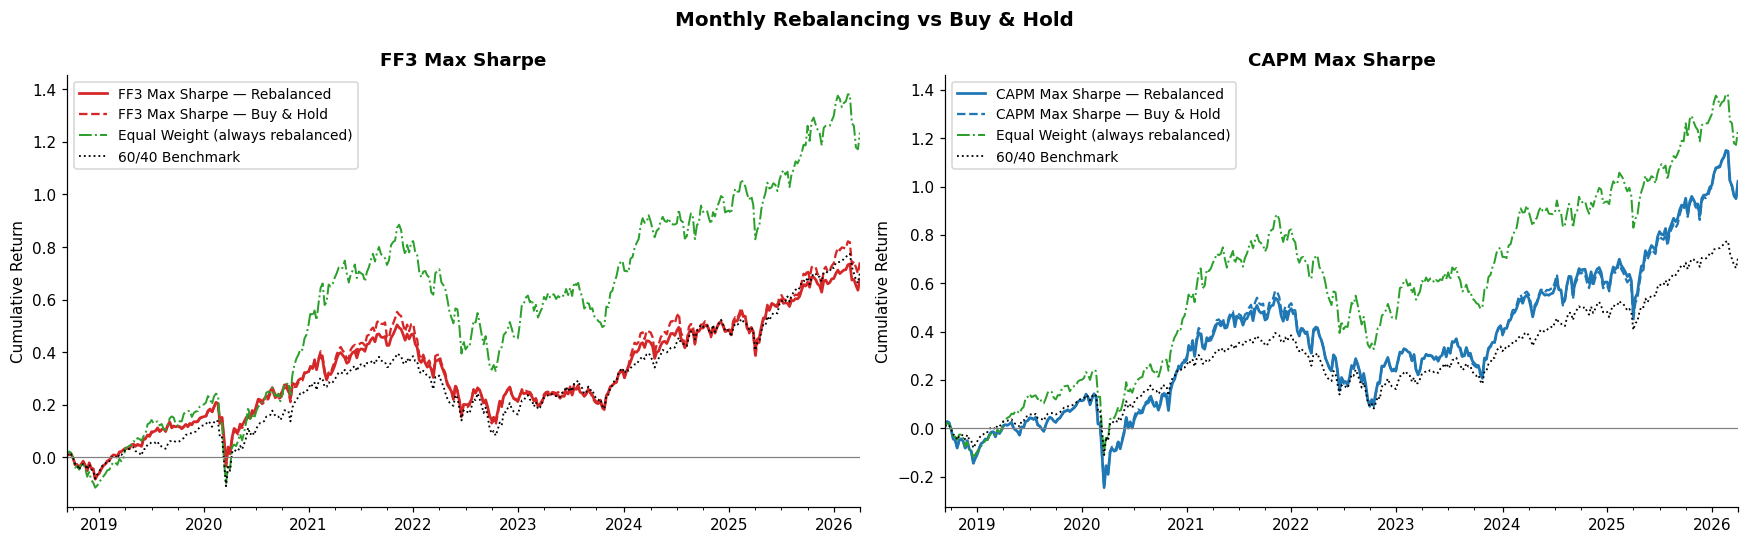

=== Rebalancing Impact ===

  FF3:
    Rebalanced — Return: 6.81%  Vol: 12.15%
    Buy & Hold — Return: 7.33%   Vol: 13.69%
    Return delta: -0.52%

  CAPM:
    Rebalanced — Return: 9.27%  Vol: 18.95%
    Buy & Hold — Return: 9.24%   Vol: 19.33%
    Return delta: +0.03%


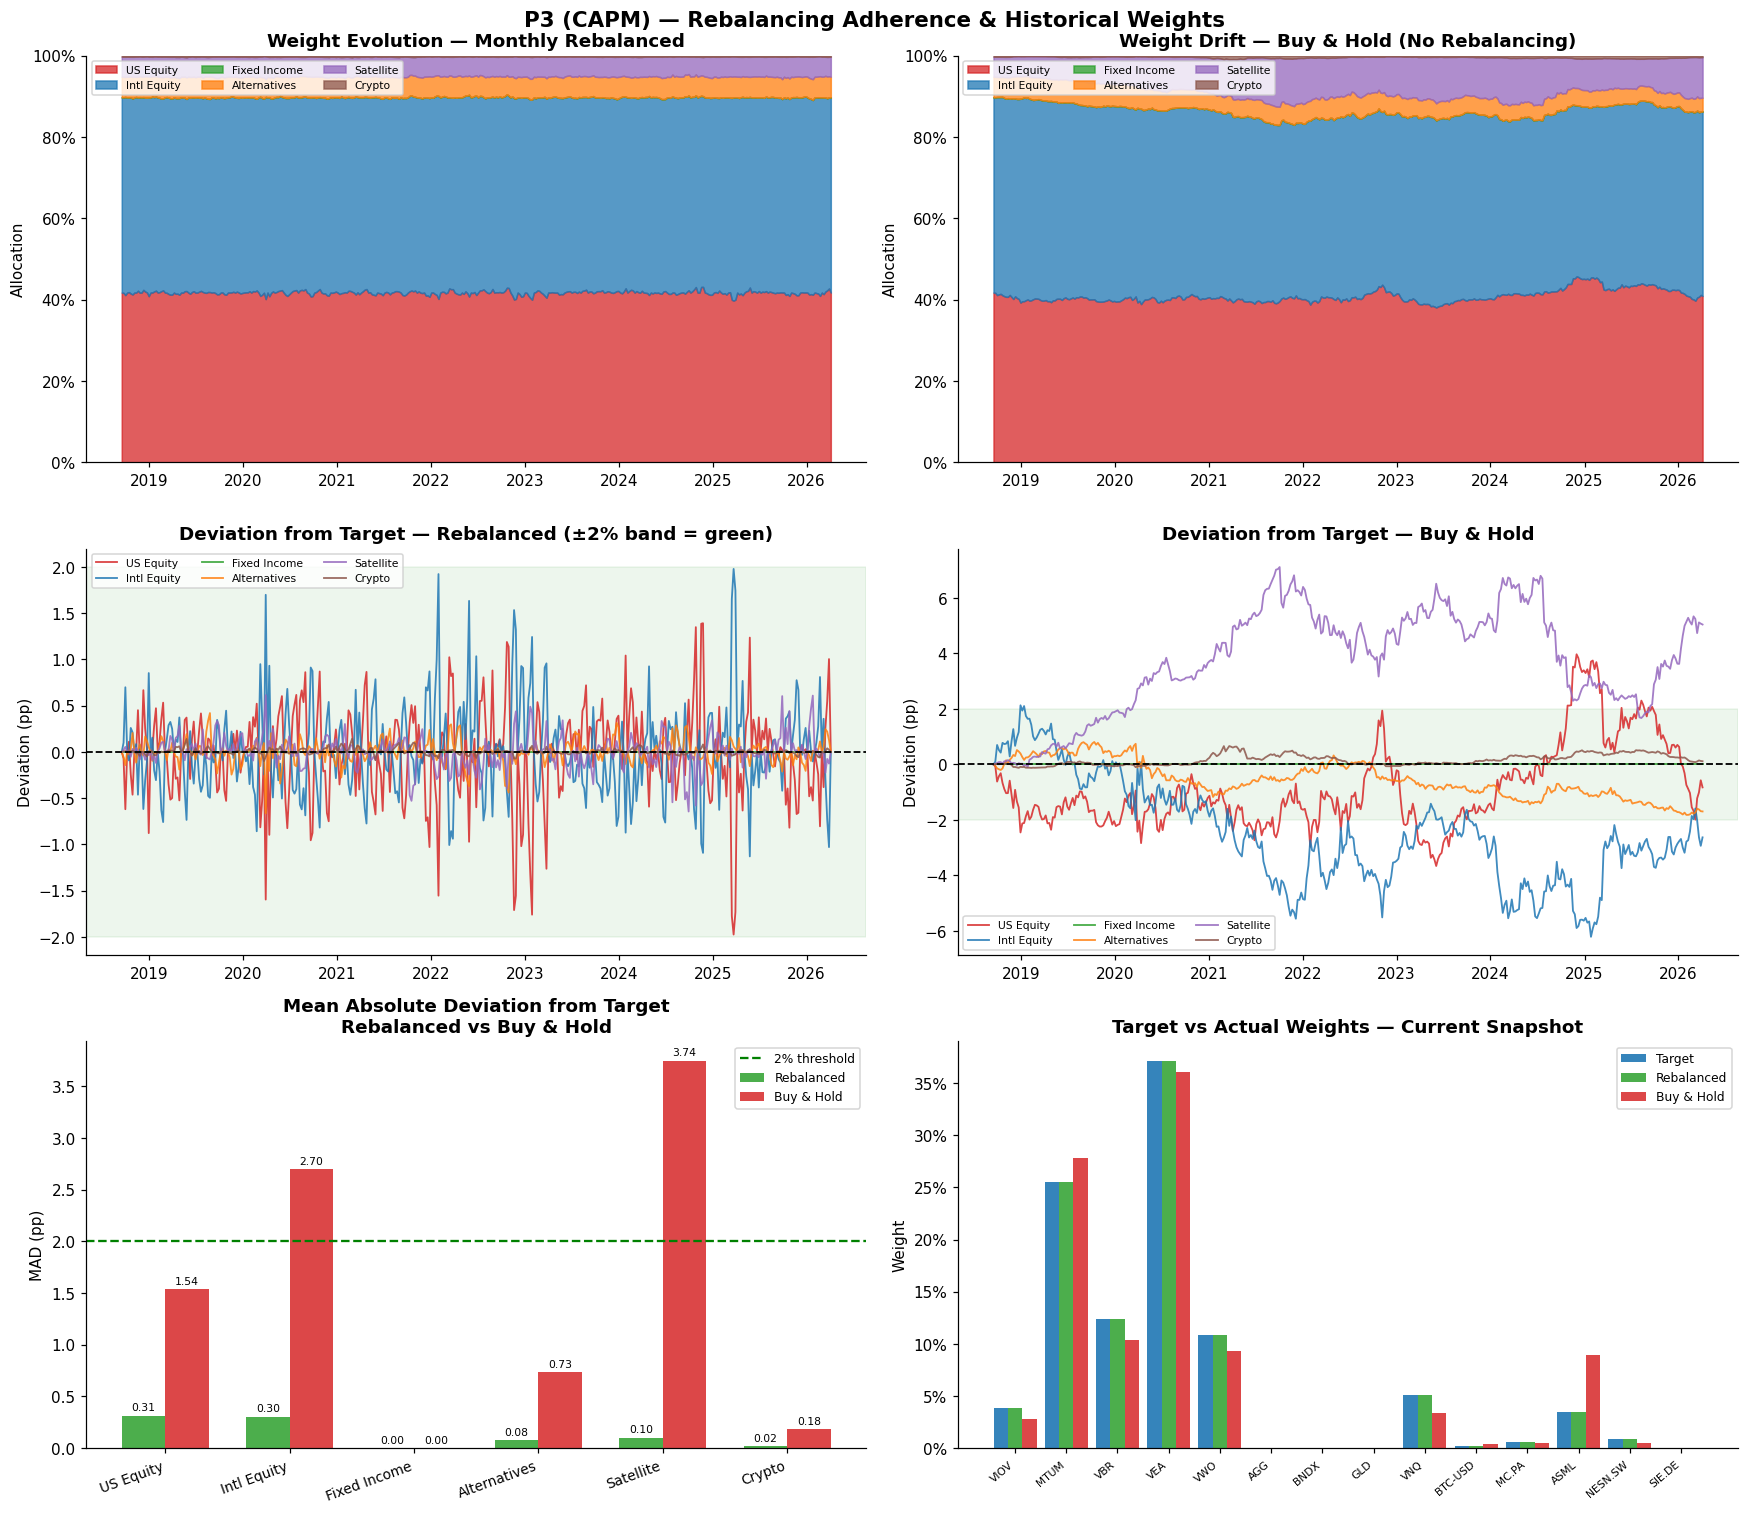


=== Performance Attribution (Annualised Contribution) ===
            FF3    CAPM      EW
Ticker                         
VBR      0.0000  0.0098  0.0057
VEA      0.0000  0.0326  0.0063
GLD      0.0000  0.0000  0.0125
SIE.DE   0.0000  0.0000  0.0096
BTC-USD  0.0000  0.0008  0.0225
MC.PA    0.0000  0.0005  0.0059
VIOV     0.0000  0.0024  0.0044
AGG      0.0000  0.0000  0.0015
VWO      0.0005  0.0074  0.0049
NESN.SW  0.0019  0.0002  0.0016
VNQ      0.0027  0.0026  0.0036
BNDX     0.0065  0.0000  0.0012
ASML     0.0150  0.0093  0.0193
MTUM     0.0442  0.0282  0.0079


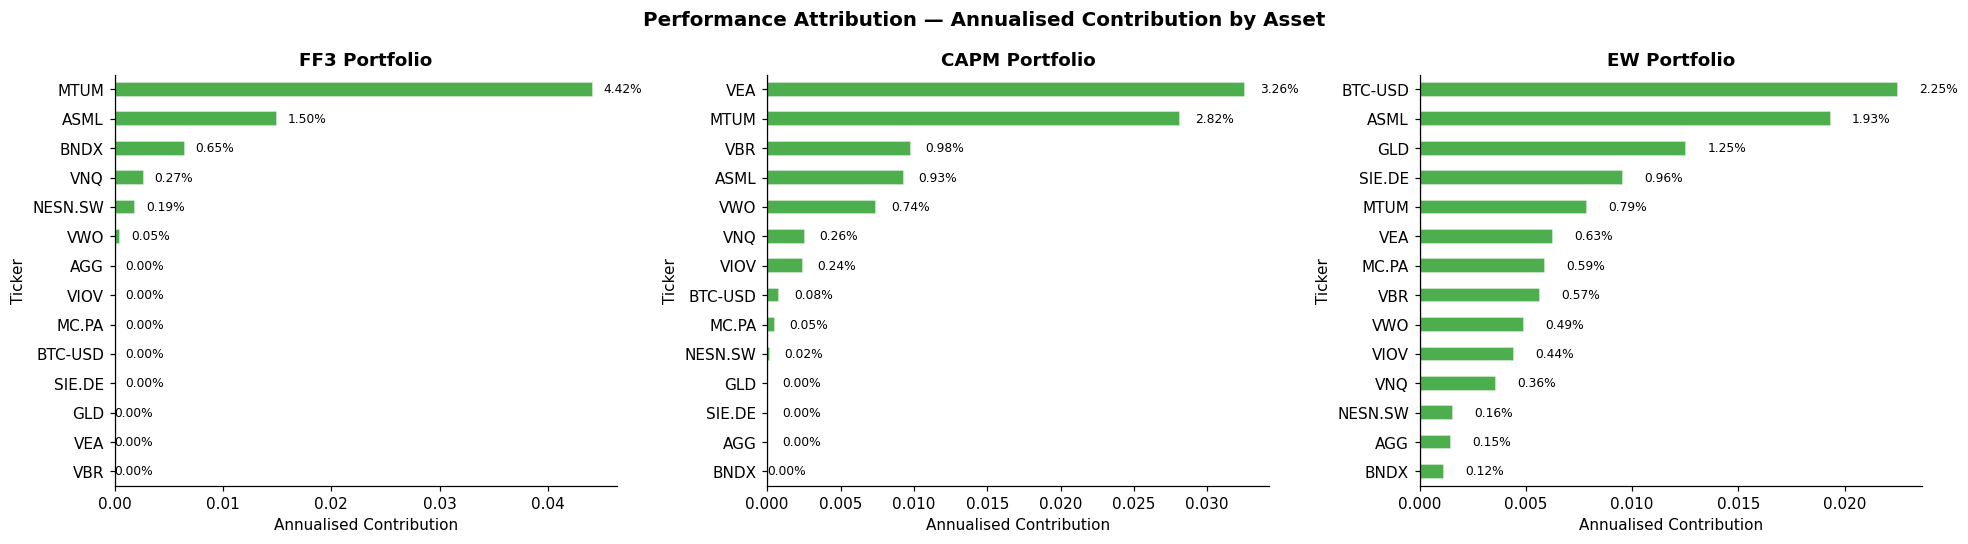

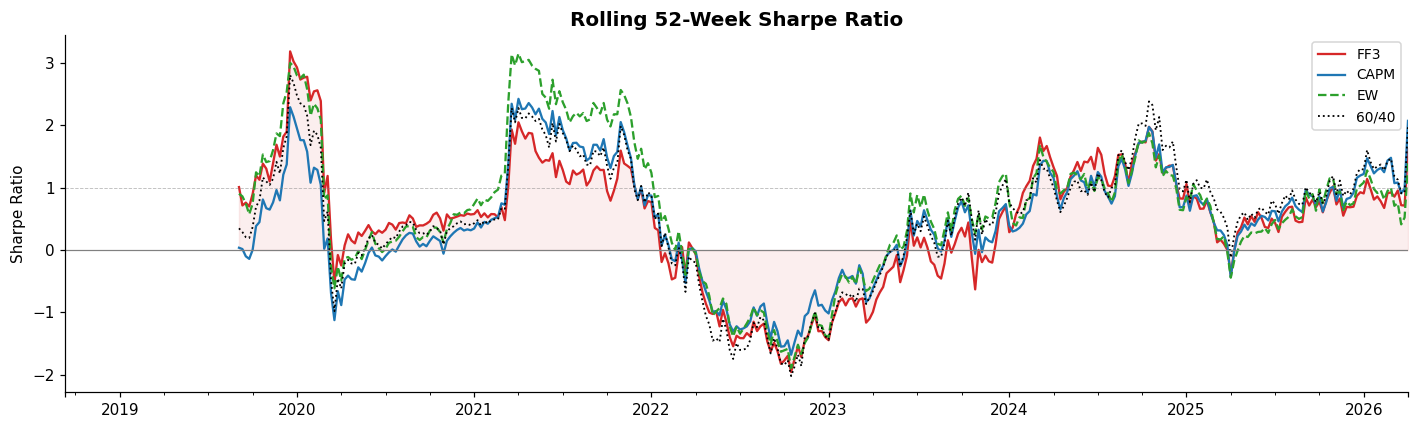

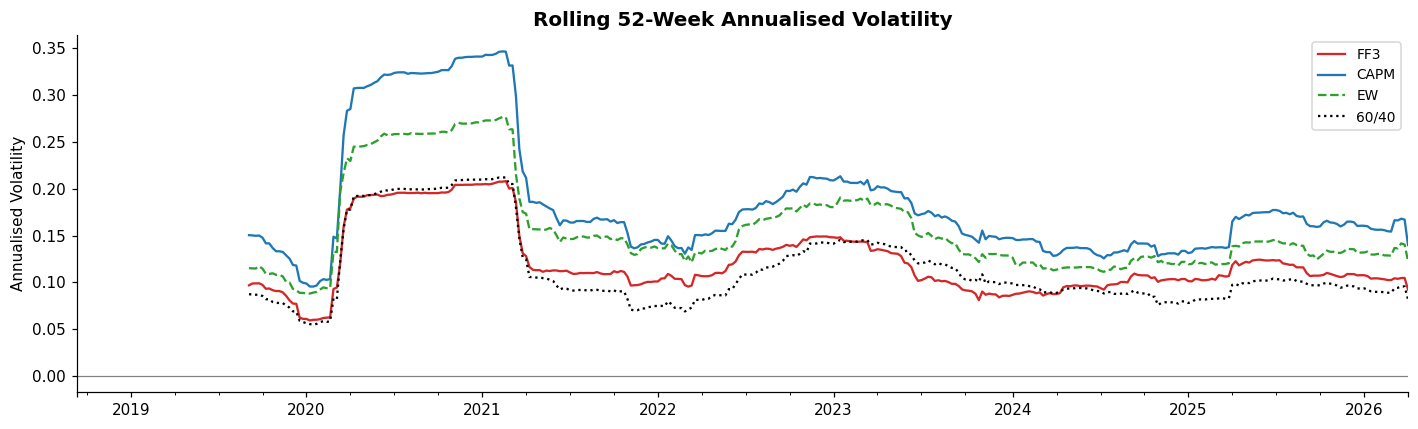

In [40]:
# ── 1. Backtest functions  ────────────────────────────────────────
def backtest_rebalanced(weights, returns_df, freq='ME'):
    """Weights reset to target at start of each month, then drift within month."""
    all_returns = []
    for _, grp in returns_df.groupby(pd.Grouper(freq=freq)):
        if len(grp) == 0:
            continue
        w = weights.copy().astype(float)        # ← reset each month
        for date, row in grp.iterrows():
            port_ret = (w * row.values).sum()   # return with drifted w
            all_returns.append(pd.Series([port_ret], index=[date]))
            w = w * (1 + row.values)            # drift
            w = w / w.sum()
    return pd.concat(all_returns).squeeze().sort_index()

def backtest_buyhold(weights, returns_df):
    """Weights set once at t=0, drift continuously, never reset."""
    all_returns = []
    w = weights.copy().astype(float)            # ← set ONCE
    for date, row in returns_df.iterrows():
        port_ret = (w * row.values).sum()
        all_returns.append(pd.Series([port_ret], index=[date]))
        w = w * (1 + row.values)
        w = w / w.sum()
    return pd.concat(all_returns).squeeze().sort_index()

port_ff3_reb  = backtest_rebalanced(w_ff3.values,  R)
port_capm_reb = backtest_rebalanced(w_capm.values, R)
port_ew_reb   = backtest_rebalanced(w_ew.values,   R)

# Buy & Hold versions (pour la comparaison)
port_ff3_bh   = backtest_buyhold(w_ff3.values,  R)
port_capm_bh  = backtest_buyhold(w_capm.values, R)


# ── 2. Weight tracking (NEW) ─────────────────────────────────────────────────
def track_weights(weights_init, returns_df, freq='ME'):
    """
    Track how weights evolve between rebalancing dates.
    Returns DataFrame of weights at each period.
    """
    all_w = []
    for _, grp in returns_df.groupby(pd.Grouper(freq=freq)):
        if len(grp) == 0:
            continue
        w = weights_init.copy().astype(float)
        for date, row in grp.iterrows():
            all_w.append(pd.Series(w, name=date))
            w = w * (1 + row.values)
            w = w / w.sum()
    return pd.DataFrame(all_w)

def track_weights_bh(weights_init, returns_df):
    """Track weight drift with NO rebalancing."""
    w = weights_init.copy().astype(float)
    all_w = []
    for date, row in returns_df.iterrows():
        all_w.append(pd.Series(w, name=date))
        w = w * (1 + row.values)
        w = w / w.sum()
    return pd.DataFrame(all_w)

# Track for CAPM (= P3 proxy) and FF3
wh_capm_reb = track_weights(w_capm.values, R)
wh_capm_bh  = track_weights_bh(w_capm.values, R)
wh_ff3_reb  = track_weights(w_ff3.values,  R)
wh_ff3_bh   = track_weights_bh(w_ff3.values,  R)

wh_capm_reb.columns = PORTFOLIO_TICKERS
wh_capm_bh.columns  = PORTFOLIO_TICKERS
wh_ff3_reb.columns  = PORTFOLIO_TICKERS
wh_ff3_bh.columns   = PORTFOLIO_TICKERS

# Asset class aggregation
ASSET_CLASSES = {
    'US Equity':    ['VIOV', 'MTUM', 'VBR'],
    'Intl Equity':  ['VEA', 'VWO'],
    'Fixed Income': ['AGG', 'BNDX'],
    'Alternatives': ['GLD', 'VNQ'],
    'Satellite':    ['MC.PA', 'ASML', 'NESN.SW', 'SIE.DE'],
    'Crypto':       ['BTC-USD'],
}
CLASS_COLORS = {
    'US Equity':    '#d62728',
    'Intl Equity':  '#1f77b4',
    'Fixed Income': '#2ca02c',
    'Alternatives': '#ff7f0e',
    'Satellite':    '#9467bd',
    'Crypto':       '#8c564b',
}

def agg_by_class(wh):
    out = pd.DataFrame(index=wh.index)
    for cls, tickers in ASSET_CLASSES.items():
        cols = [t for t in tickers if t in wh.columns]
        out[cls] = wh[cols].sum(axis=1)
    return out

cw_capm_reb = agg_by_class(wh_capm_reb)
cw_capm_bh  = agg_by_class(wh_capm_bh)

target_capm = pd.Series({
    cls: w_capm[[t for t in tks if t in PORTFOLIO_TICKERS]].sum()
    for cls, tks in ASSET_CLASSES.items()
})

# ── 3. Rebalanced vs Buy & Hold comparison (existing) ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Monthly Rebalancing vs Buy & Hold', fontweight='bold', fontsize=13)

for ax, (port_reb, port_bh, label, color) in zip(axes, [
    (port_ff3_reb,  port_ff3_bh,  'FF3 Max Sharpe',  '#d62728'),
    (port_capm_reb, port_capm_bh, 'CAPM Max Sharpe', '#1f77b4'),
]):
    (np.exp(port_reb.cumsum()) - 1).plot(
        ax=ax, label=f'{label} — Rebalanced', color=color, lw=1.8)
    (np.exp(port_bh.cumsum())  - 1).plot(
        ax=ax, label=f'{label} — Buy & Hold', color=color, lw=1.5, linestyle='--')
    (np.exp(port_ew_reb.cumsum()) - 1).plot(
        ax=ax, label='Equal Weight (always rebalanced)',
        color='#2ca02c', lw=1.3, linestyle='-.')
    (np.exp(bench_6040.cumsum()) - 1).plot(
        ax=ax, label='60/40 Benchmark', color='black', lw=1.2, linestyle=':')
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Cumulative Return')
    ax.axhline(0, color='grey', lw=0.8)
    ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# Rebalancing impact table
print('=== Rebalancing Impact ===')
for port_reb, port_bh, label in [
    (port_ff3_reb,  port_ff3_bh,  'FF3'),
    (port_capm_reb, port_capm_bh, 'CAPM'),
]:
    ret_reb = port_reb.mean() * 52; ret_bh = port_bh.mean() * 52
    vol_reb = port_reb.std()  * np.sqrt(52); vol_bh = port_bh.std() * np.sqrt(52)
    print(f"\n  {label}:")
    print(f"    Rebalanced — Return: {ret_reb:.2%}  Vol: {vol_reb:.2%}")
    print(f"    Buy & Hold — Return: {ret_bh:.2%}   Vol: {vol_bh:.2%}")
    print(f"    Return delta: {ret_reb - ret_bh:+.2%}")

# ── 4. Historical weights — adherence (NEW) ──────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('P3 (CAPM) — Rebalancing Adherence & Historical Weights',
             fontweight='bold', fontsize=14)

# Panel 1: stacked area rebalanced
ax = axes[0, 0]
bottom = np.zeros(len(cw_capm_reb))
for cls in ASSET_CLASSES:
    ax.fill_between(cw_capm_reb.index, bottom,
                    bottom + cw_capm_reb[cls].values,
                    alpha=0.75, color=CLASS_COLORS[cls], label=cls)
    bottom += cw_capm_reb[cls].values
ax.set_title('Weight Evolution — Monthly Rebalanced', fontweight='bold')
ax.set_ylabel('Allocation')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(fontsize=7, ncol=3, loc='upper left')
ax.set_ylim(0, 1)

# Panel 2: stacked area buy & hold
ax = axes[0, 1]
bottom = np.zeros(len(cw_capm_bh))
for cls in ASSET_CLASSES:
    ax.fill_between(cw_capm_bh.index, bottom,
                    bottom + cw_capm_bh[cls].values,
                    alpha=0.75, color=CLASS_COLORS[cls], label=cls)
    bottom += cw_capm_bh[cls].values
ax.set_title('Weight Drift — Buy & Hold (No Rebalancing)', fontweight='bold')
ax.set_ylabel('Allocation')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(fontsize=7, ncol=3, loc='upper left')
ax.set_ylim(0, 1)

# Panel 3: deviation from target — rebalanced
ax = axes[1, 0]
for cls in ASSET_CLASSES:
    dev = (cw_capm_reb[cls] - target_capm[cls]) * 100
    ax.plot(dev.index, dev.values, color=CLASS_COLORS[cls],
            lw=1.2, label=cls, alpha=0.85)
ax.axhline(0, color='black', lw=1.2, linestyle='--')
ax.axhspan(-2, 2, alpha=0.07, color='green')
ax.set_title('Deviation from Target — Rebalanced (±2% band = green)',
             fontweight='bold')
ax.set_ylabel('Deviation (pp)')
ax.legend(fontsize=7, ncol=3)

# Panel 4: deviation from target — buy & hold
ax = axes[1, 1]
for cls in ASSET_CLASSES:
    dev = (cw_capm_bh[cls] - target_capm[cls]) * 100
    ax.plot(dev.index, dev.values, color=CLASS_COLORS[cls],
            lw=1.2, label=cls, alpha=0.85)
ax.axhline(0, color='black', lw=1.2, linestyle='--')
ax.axhspan(-2, 2, alpha=0.07, color='green')
ax.set_title('Deviation from Target — Buy & Hold', fontweight='bold')
ax.set_ylabel('Deviation (pp)')
ax.legend(fontsize=7, ncol=3)

# Panel 5: mean absolute deviation comparison
ax = axes[2, 0]
mad_reb = {cls: (cw_capm_reb[cls] - target_capm[cls]).abs().mean() * 100
           for cls in ASSET_CLASSES}
mad_bh  = {cls: (cw_capm_bh[cls]  - target_capm[cls]).abs().mean() * 100
           for cls in ASSET_CLASSES}
x = np.arange(len(ASSET_CLASSES)); w_bar = 0.35
ax.bar(x - w_bar/2, mad_reb.values(), w_bar, label='Rebalanced',
       color='#2ca02c', alpha=0.85)
ax.bar(x + w_bar/2, mad_bh.values(),  w_bar, label='Buy & Hold',
       color='#d62728', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(ASSET_CLASSES.keys(), rotation=20, ha='right', fontsize=9)
ax.axhline(2, color='green', lw=1.5, linestyle='--', label='2% threshold')
ax.set_title('Mean Absolute Deviation from Target\nRebalanced vs Buy & Hold',
             fontweight='bold')
ax.set_ylabel('MAD (pp)')
ax.legend(fontsize=8)
for i, (r, b) in enumerate(zip(mad_reb.values(), mad_bh.values())):
    ax.text(i - w_bar/2, r + 0.05, f'{r:.2f}', ha='center', fontsize=7)
    ax.text(i + w_bar/2, b + 0.05, f'{b:.2f}', ha='center', fontsize=7)

# Panel 6: target vs current snapshot
ax = axes[2, 1]
actual_reb = wh_capm_reb.iloc[-1]
actual_bh  = wh_capm_bh.iloc[-1]
x = np.arange(len(PORTFOLIO_TICKERS)); w_bar = 0.28
ax.bar(x - w_bar, w_capm.values,      w_bar, label='Target',
       color='#1f77b4', alpha=0.9)
ax.bar(x,         actual_reb.values,  w_bar, label='Rebalanced',
       color='#2ca02c', alpha=0.85)
ax.bar(x + w_bar, actual_bh.values,   w_bar, label='Buy & Hold',
       color='#d62728', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(PORTFOLIO_TICKERS, rotation=40, ha='right', fontsize=7)
ax.set_title('Target vs Actual Weights — Current Snapshot', fontweight='bold')
ax.set_ylabel('Weight')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# ── 5. Performance attribution (existing) ───────────────────────────────────
contrib_ff3  = (R * w_ff3.values).mean()  * 52
contrib_capm = (R * w_capm.values).mean() * 52
contrib_ew   = (R * w_ew.values).mean()   * 52
contrib_df   = pd.DataFrame({
    'FF3': contrib_ff3, 'CAPM': contrib_capm, 'EW': contrib_ew,
}).sort_values('FF3', ascending=True)

print('\n=== Performance Attribution (Annualised Contribution) ===')
print(contrib_df.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Performance Attribution — Annualised Contribution by Asset',
             fontweight='bold', fontsize=13)
for ax, (col, color) in zip(axes, [
    ('FF3', '#d62728'), ('CAPM', '#1f77b4'), ('EW', '#2ca02c')
]):
    c_sorted   = contrib_df[col].sort_values()
    bar_colors = ['#d62728' if v < 0 else '#2ca02c' for v in c_sorted]
    c_sorted.plot(kind='barh', ax=ax, color=bar_colors,
                  alpha=0.85, edgecolor='white')
    for i, (idx, v) in enumerate(c_sorted.items()):
        ax.text(v + np.sign(v) * 0.001, i, f'{v:.2%}',
                va='center', ha='left' if v >= 0 else 'right', fontsize=8)
    ax.axvline(0, color='grey', lw=0.8)
    ax.set_title(f'{col} Portfolio', fontweight='bold')
    ax.set_xlabel('Annualised Contribution')
plt.tight_layout(); plt.show()

# ── 6. Rolling Sharpe (existing) ────────────────────────────────────────────
def rolling_sharpe(series, rf_ann, window=52):
    roll_ret = series.rolling(window).mean() * 52
    roll_vol = series.rolling(window).std()  * np.sqrt(52)
    return (roll_ret - rf_ann) / roll_vol

fig, ax = plt.subplots(figsize=(13, 4))
rolling_sharpe(port_ff3,   rf_annual).plot(ax=ax, label='FF3',       color='#d62728', lw=1.5)
rolling_sharpe(port_capm,  rf_annual).plot(ax=ax, label='CAPM',      color='#1f77b4', lw=1.5)
rolling_sharpe(port_ew,    rf_annual).plot(ax=ax, label='EW',        color='#2ca02c', lw=1.5, ls='--')
rolling_sharpe(bench_6040, rf_annual).plot(ax=ax, label='60/40',     color='black',   lw=1.2, ls=':')
ax.axhline(0, color='grey', lw=0.8)
ax.axhline(1, color='grey', lw=0.6, linestyle='--', alpha=0.5)
ax.fill_between(port_ff3.index, rolling_sharpe(port_ff3, rf_annual),
                0, alpha=0.08, color='#d62728')
ax.set_title('Rolling 52-Week Sharpe Ratio', fontweight='bold', fontsize=13)
ax.set_ylabel('Sharpe Ratio'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# ── 7. Rolling Volatility (existing) ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
for port, label, color, ls in [
    (port_ff3,   'FF3',   '#d62728', '-'),
    (port_capm,  'CAPM',  '#1f77b4', '-'),
    (port_ew,    'EW',    '#2ca02c', '--'),
    (bench_6040, '60/40', 'black',   ':'),
]:
    (port.rolling(52).std() * np.sqrt(52)).plot(
        ax=ax, label=label, color=color, lw=1.5, linestyle=ls)
ax.set_title('Rolling 52-Week Annualised Volatility', fontweight='bold', fontsize=13)
ax.set_ylabel('Annualised Volatility')
ax.axhline(0, color='grey', lw=0.8); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 8. Glide Path Simulation

Réduction systématique de l'exposition actions de **80% → 40%** sur les 10 dernières années du backtest.

FF3 equity allocation at glide path start: 100.0%
Annual reduction: 4.0% per year

Equity pocket weights:
VIOV       0.039
MTUM       0.255
VBR        0.124
VEA        0.371
VWO        0.108
GLD        0.000
VNQ        0.051
BTC-USD    0.003
MC.PA      0.006
ASML       0.034
NESN.SW    0.008
SIE.DE     0.000
dtype: float64

Bond pocket weights:
AGG     1.0
BNDX    0.0
dtype: float64


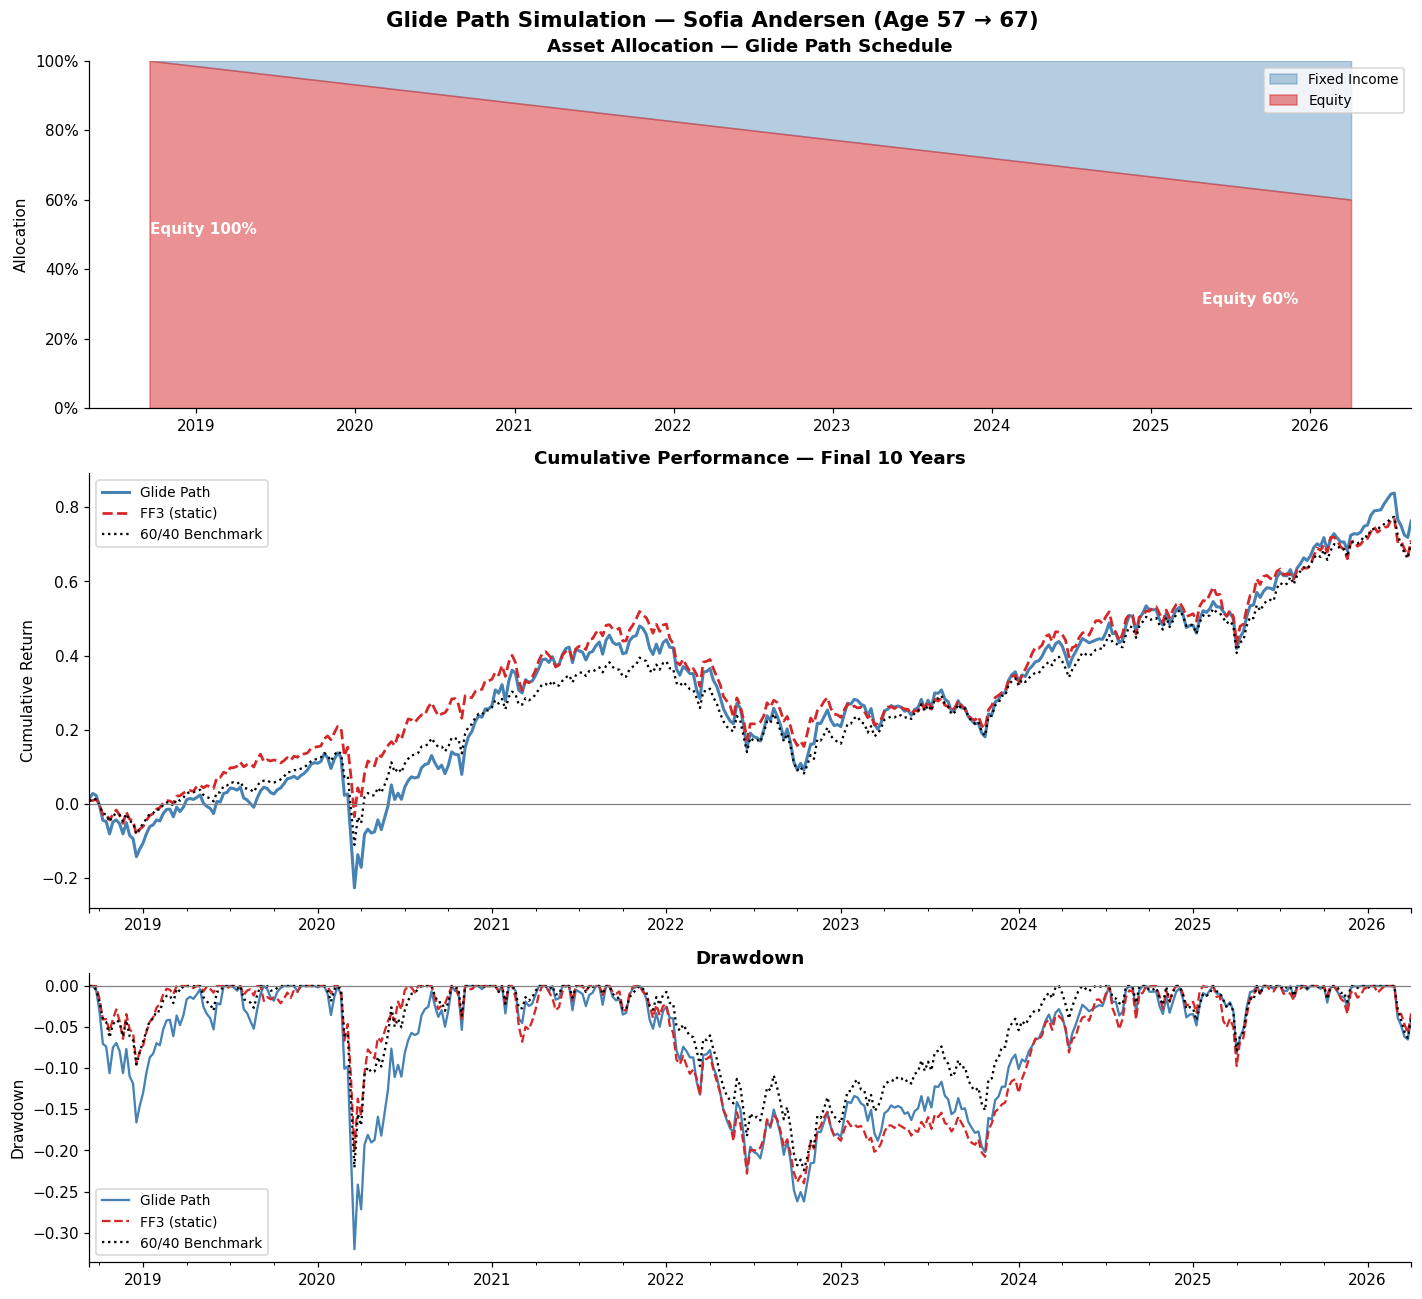


=== Glide Path — Performance Summary ===
  Annualized Return : 7.46%
  Annualized Vol    : 16.36%
  Sharpe Ratio      : 0.285
  Sortino Ratio     : 0.336
  Max Drawdown      : -32.00%

  Starting equity allocation : 100.0%
  Ending equity allocation   : 60.0%
  Annual reduction           : 4.0% per year


In [41]:
# ── Glide Path — Sofia Andersen (Age 57 → 67) ───────────────────────────────

# ── 1. Setup ─────────────────────────────────────────────────────────────────
gp_start = R.index[-1] - pd.DateOffset(years=10)
gp_dates = R.index[R.index >= gp_start]
n_weeks  = len(gp_dates)

# Asset classification
BOND_ASSETS   = ['AGG', 'BNDX']
CASH_ASSETS   = []  # could add T-Bill proxy here
EQUITY_ASSETS = [t for t in PORTFOLIO_TICKERS
                 if t not in BOND_ASSETS + CASH_ASSETS]

# ── 2. Starting equity allocation from FF3 optimal weights ───────────────────
# Use actual FF3 equity allocation as starting point (not arbitrary 80%)
eq_share_capm = w_capm[EQUITY_ASSETS].sum()
print(f"FF3 equity allocation at glide path start: {eq_share_capm:.1%}")

# Glide path: reduce by 1pp per year (case study requirement)
# From current equity share → 60% at retirement
yearly_reduction = (eq_share_capm - 0.60) / 10
print(f"Annual reduction: {yearly_reduction:.1%} per year")

# Weekly interpolation
eq_alloc_gp   = np.linspace(float(eq_share_capm), 0.60, n_weeks)
bond_alloc_gp = 1 - eq_alloc_gp

# ── 3. Intra-pocket weights (from FF3 optimisation, normalised) ──────────────
# Equity pocket: use FF3 weights, normalised to sum to 1
w_eq_norm   = w_capm[EQUITY_ASSETS] / w_capm[EQUITY_ASSETS].sum()
# Bond pocket: use FF3 weights if available, else equal weight
w_bond_norm = (w_capm[BOND_ASSETS] / w_capm[BOND_ASSETS].sum()
               if w_capm[BOND_ASSETS].sum() > 0
               else pd.Series({t: 1/len(BOND_ASSETS) for t in BOND_ASSETS}))

print(f"\nEquity pocket weights:\n{w_eq_norm.round(3)}")
print(f"\nBond pocket weights:\n{w_bond_norm.round(3)}")

R_gp     = R.loc[gp_dates]
ret_eq   = (R_gp[EQUITY_ASSETS] * w_eq_norm.values).sum(axis=1).values
ret_bond = (R_gp[BOND_ASSETS]   * w_bond_norm.values).sum(axis=1).values

gp_returns = pd.Series(
    eq_alloc_gp * ret_eq + bond_alloc_gp * ret_bond,
    index=gp_dates, name='Glide Path'
)

# ── 4. Visualisation ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 12),
                          gridspec_kw={'height_ratios': [1.2, 1.5, 1]})
fig.suptitle('Glide Path Simulation — Sofia Andersen (Age 57 → 67)',
             fontweight='bold', fontsize=14)

# Panel 1: Allocation over time
axes[0].fill_between(gp_dates, eq_alloc_gp, 1,
                     alpha=0.40, color='steelblue', label='Fixed Income')
axes[0].fill_between(gp_dates, 0, eq_alloc_gp,
                     alpha=0.50, color='#d62728',   label='Equity')
# Annotate start and end allocations
axes[0].annotate(f'Equity {eq_alloc_gp[0]:.0%}',
                 xy=(gp_dates[0], eq_alloc_gp[0]/2),
                 color='white', fontweight='bold', fontsize=10)
axes[0].annotate(f'Equity 60%',
                 xy=(gp_dates[-50], 0.30),
                 color='white', fontweight='bold', fontsize=10)
axes[0].set_ylabel('Allocation')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[0].set_title('Asset Allocation — Glide Path Schedule', fontweight='bold')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].set_ylim(0, 1)

# Panel 2: Cumulative performance
(np.exp(gp_returns.cumsum()) - 1).plot(
    ax=axes[1], label='Glide Path',    color='steelblue', lw=2)
(np.exp(port_ff3.loc[gp_dates].cumsum()) - 1).plot(
    ax=axes[1], label='FF3 (static)',  color='#d62728',   lw=1.8, linestyle='--')
(np.exp(bench_6040.loc[gp_dates].cumsum()) - 1).plot(
    ax=axes[1], label='60/40 Benchmark', color='black',   lw=1.5, linestyle=':')
axes[1].set_title('Cumulative Performance — Final 10 Years', fontweight='bold')
axes[1].set_ylabel('Cumulative Return')
axes[1].axhline(0, color='grey', lw=0.8)
axes[1].legend(fontsize=9)

# Panel 3: Drawdown
for port, label, color, ls in [
    (gp_returns,              'Glide Path',     'steelblue', '-'),
    (port_ff3.loc[gp_dates],  'FF3 (static)',   '#d62728',   '--'),
    (bench_6040.loc[gp_dates],'60/40 Benchmark','black',     ':'),
]:
    cum = np.exp(port.cumsum())
    dd  = cum / cum.cummax() - 1
    dd.plot(ax=axes[2], label=label, color=color, lw=1.5, linestyle=ls)
axes[2].set_title('Drawdown', fontweight='bold')
axes[2].set_ylabel('Drawdown')
axes[2].axhline(0, color='grey', lw=0.8)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── 5. Performance metrics (weekly returns → annualise ×52) ──────────────────
gp_ann_ret = gp_returns.mean() * 52
gp_ann_vol = gp_returns.std()  * np.sqrt(52)
gp_cum     = np.exp(gp_returns.cumsum())
gp_dd      = (gp_cum / gp_cum.cummax() - 1).min()
gp_sr      = (gp_ann_ret - rf_annual) / gp_ann_vol
gp_sortino = (gp_ann_ret - rf_annual) / \
             (gp_returns[gp_returns < 0].std() * np.sqrt(52))

print('\n=== Glide Path — Performance Summary ===')
print(f"  Annualized Return : {gp_ann_ret:.2%}")
print(f"  Annualized Vol    : {gp_ann_vol:.2%}")
print(f"  Sharpe Ratio      : {gp_sr:.3f}")
print(f"  Sortino Ratio     : {gp_sortino:.3f}")
print(f"  Max Drawdown      : {gp_dd:.2%}")
print(f"\n  Starting equity allocation : {eq_alloc_gp[0]:.1%}")
print(f"  Ending equity allocation   : {eq_alloc_gp[-1]:.1%}")
print(f"  Annual reduction           : {yearly_reduction:.1%} per year")

## 9. Asynchronous Trading Adjustment

US, European, and Asian markets do not close simultaneously. Correlations computed on **daily** data underestimate true cross-asset dependencies. Solution: **weekly returns** (Friday-to-Friday close) — already applied throughout this notebook.


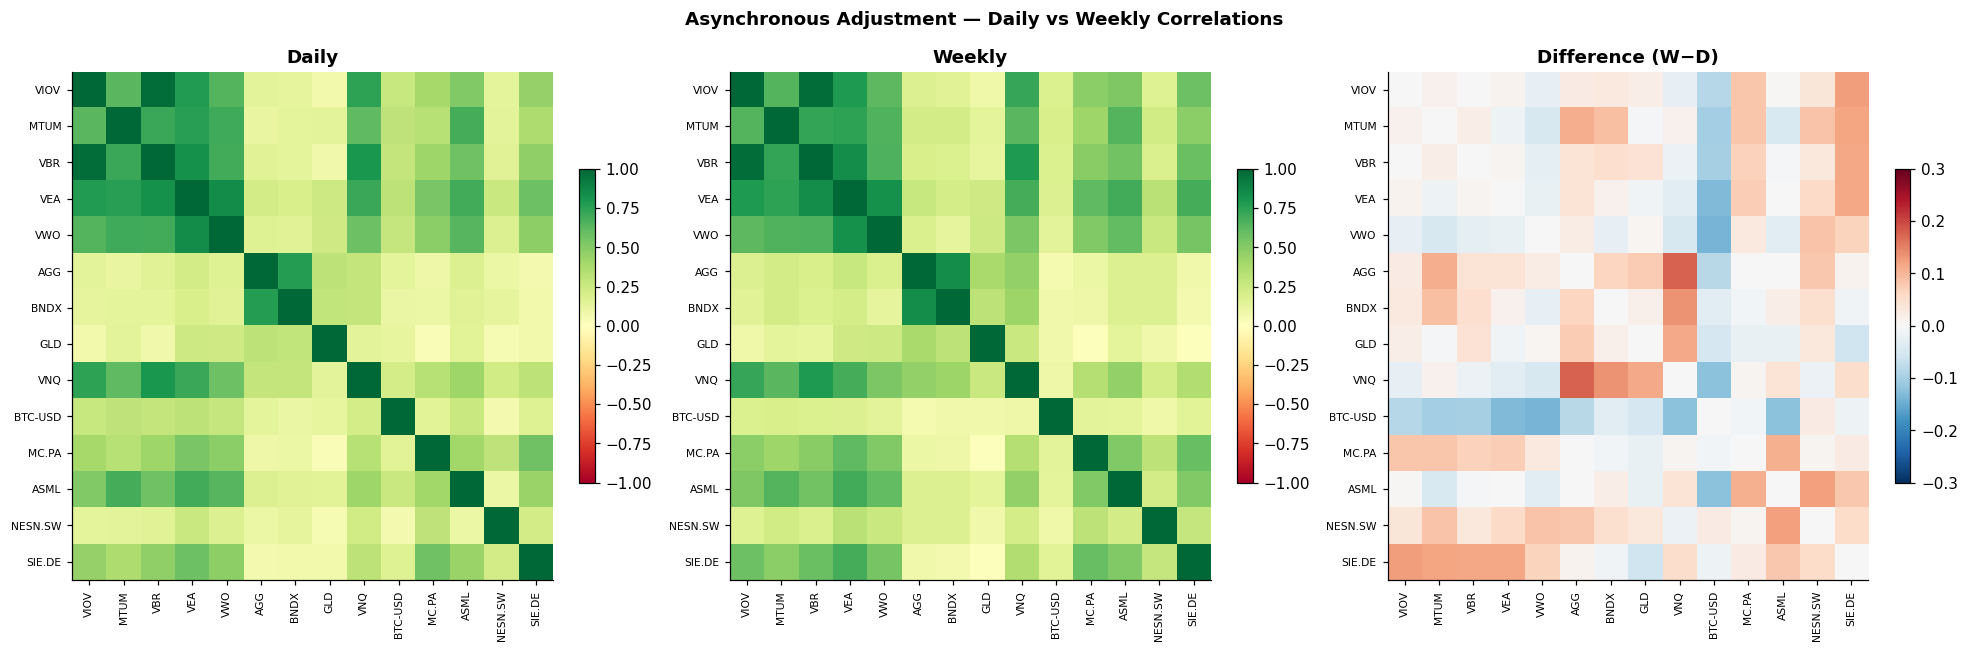

=== Betas FF6 — Daily vs Weekly (US Equity) ===

Journalier :
      Mkt-RF     SMB     HML     RMW     CMA     Mom
VIOV  1.0136  0.9235  0.3592  0.1941  0.1133 -0.0571
MTUM  1.0994 -0.1272  0.0671 -0.1840 -0.0214  0.3956
VBR   1.0503  0.6093  0.4020  0.1083  0.0077  0.0134

Hebdomadaire :
      Mkt-RF  SMB  HML  RMW  CMA  Mom
VIOV     0.0  0.0  0.0  0.0  0.0  0.0
MTUM     0.0  0.0  0.0  0.0  0.0  0.0
VBR      0.0  0.0  0.0  0.0  0.0  0.0

=== Impact on correlations across regions ===
Combination                   Daily         Weekly        Δ
VIOV / MC.PA                  0.397          0.480    0.083
MTUM / ASML                   0.687          0.641   -0.045
VBR / NESN.SW                 0.157          0.188    0.031
VEA / VWO                     0.845          0.823   -0.022


In [42]:
# Resample to weekly (Friday close)
weekly_prices_fri  = prices.resample('W-FRI').last()
weekly_returns_fri = np.log(weekly_prices_fri / weekly_prices_fri.shift(1)).dropna()

# Daily correlations (from raw daily prices, for valid comparison)
daily_returns_raw = np.log(prices_raw[PORTFOLIO_TICKERS] / prices_raw[PORTFOLIO_TICKERS].shift(1)).dropna()
daily_corr  = daily_returns_raw.corr()
weekly_corr = weekly_returns_fri.corr()
diff_corr   = weekly_corr - daily_corr


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Asynchronous Adjustment — Daily vs Weekly Correlations', fontsize=12, fontweight='bold')
for ax, (mat, title, vmin, vmax, cmap) in zip(axes, [
    (daily_corr,  'Daily',      -1,    1,   'RdYlGn'),
    (weekly_corr, 'Weekly',     -1,    1,   'RdYlGn'),
    (diff_corr,   'Difference (W−D)', -0.3,  0.3, 'RdBu_r'),
]):
    im = ax.imshow(mat.values, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(PORTFOLIO_TICKERS)))
    ax.set_yticks(range(len(PORTFOLIO_TICKERS)))
    ax.set_xticklabels(mat.columns, rotation=90, fontsize=7)
    ax.set_yticklabels(mat.index, fontsize=7)
    ax.set_title(title, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout(); plt.show()

# Régression FF6 sur rendements hebdomadaires — US Equity
ff6_weekly = ff6_all.resample('W-FRI').sum()   # somme des facteurs quotidiens sur la semaine
rf_weekly  = F['RF'].resample('W-FRI').sum()
w_idx      = weekly_returns.index.intersection(ff6_weekly.index).intersection(rf_weekly.index)
wR = weekly_returns.loc[w_idx, US_SUB]
wF = ff6_weekly.loc[w_idx, FACTORS_FF6]
wRF= rf_weekly.loc[w_idx]

betas_ff6_wk = {}
for t in US_SUB:
    excess = (wR[t] - wRF).values
    X = np.column_stack([np.ones(len(wF)), wF.values])
    coeffs,_,_,_ = np.linalg.lstsq(X, excess, rcond=None)
    betas_ff6_wk[t] = dict(zip(FACTORS_FF6, coeffs[1:]))

betas_ff6_wk_df = pd.DataFrame(betas_ff6_wk).T
print('=== Betas FF6 — Daily vs Weekly (US Equity) ===\n')
print('Journalier :'); print(betas_ff6_df.round(4))
print('\nHebdomadaire :'); print(betas_ff6_wk_df.round(4))

# Impact sur la matrice de corrélation — paires cross-régions
cross_pairs = [('VIOV','MC.PA'),('MTUM','ASML'),('VBR','NESN.SW'),('VEA','VWO')]
print('\n=== Impact on correlations across regions ===')
print(f'{"Combination":<20} {"Daily":>14} {"Weekly":>14} {"Δ":>8}')
for a,b in cross_pairs:
    if a in daily_corr.columns and b in daily_corr.columns:
        d=daily_corr.loc[a,b]; w=weekly_corr.loc[a,b]
        print(f'{a+" / "+b:<20} {d:>14.3f} {w:>14.3f} {w-d:>8.3f}')

In [43]:
from IPython.display import Markdown, display
import pandas as pd
import numpy as np

# ============================================================================
# HELPER FUNCTIONS FOR ADDITIONAL METRICS
# ============================================================================

def calculate_var(returns, confidence=0.95):
    """Calculate Value at Risk at given confidence level"""
    return np.percentile(returns, (1 - confidence) * 100)

def calculate_sortino(returns, annual_return, rf=0.02):
    """Calculate Sortino Ratio (downside volatility only)"""
    downside_returns = returns[returns < 0]
    if len(downside_returns) == 0:
        return np.nan
    downside_vol = downside_returns.std() * np.sqrt(252)  # Weekly to annual
    return (annual_return - rf) / downside_vol if downside_vol > 0 else np.nan

def calculate_calmar(annual_return, max_drawdown):
    """Calculate Calmar Ratio = Return / |Max Drawdown|"""
    if max_drawdown == 0:
        return np.nan
    return annual_return / abs(max_drawdown)

# ============================================================================
# CREATE METRICS TABLE (8 Portfolios)
# ============================================================================

metrics = pd.concat([
    perf_metrics(port_ff3,          rf_annual, 'FF3 Max Sharpe'),
    perf_metrics(port_ff3_reb,      rf_annual, 'FF3 Max Sharpe Rebalanced'),
    perf_metrics(port_capm,         rf_annual, 'CAPM Max Sharpe'),
    perf_metrics(port_capm_reb,     rf_annual, 'CAPM Max Sharpe Rebalanced'),
    perf_metrics(port_ew,           rf_annual, 'Equal Weight'),
    perf_metrics(port_ew_reb,       rf_annual, 'Equal Weight Rebalanced'),
    perf_metrics(port_vt,           rf_annual, 'VT Benchmark'),
    perf_metrics(bench_6040,        rf_annual, '60/40 Benchmark'),
], axis=1)

# ============================================================================
# EXTRACT BASE METRICS
# ============================================================================

portfolio_names = [
    'FF3 Max Sharpe',
    'FF3 Max Sharpe Rebalanced',
    'CAPM Max Sharpe',
    'CAPM Max Sharpe Rebalanced',
    'Equal Weight',
    'Equal Weight Rebalanced',
    'VT Benchmark',
    '60/40 Benchmark'
]

portfolio_returns = [
    port_ff3,
    port_ff3_reb,
    port_capm,
    port_capm_reb,
    port_ew,
    port_ew_reb,
    port_vt,
    bench_6040
]

# Extract base metrics
sharpe_ratios = metrics.loc['Sharpe Ratio'].to_dict()
annualized_returns = metrics.loc['Annualized Return'].to_dict()
max_drawdowns = metrics.loc['Max Drawdown'].to_dict()

# ============================================================================
# CALCULATE ADDITIONAL METRICS
# ============================================================================

var_95 = {}
sortino_ratios = {}
calmar_ratios = {}

for name, returns in zip(portfolio_names, portfolio_returns):
    # VaR (95% confidence level)
    var_95[name] = calculate_var(returns.values, confidence=0.95)
    
    # Sortino Ratio
    annual_ret = annualized_returns[name]
    sortino_ratios[name] = calculate_sortino(returns, annual_ret, rf=rf_annual)
    
    # Calmar Ratio
    max_dd = max_drawdowns[name]
    calmar_ratios[name] = calculate_calmar(annual_ret, max_dd)

# ============================================================================
# BUILD COMPREHENSIVE METRICS DICTIONARY
# ============================================================================

portfolios_metrics = {}
for name in portfolio_names:
    portfolios_metrics[name] = {
        'sharpe': sharpe_ratios[name],
        'return': annualized_returns[name],
        'drawdown': max_drawdowns[name],
        'var_95': var_95[name],
        'sortino': sortino_ratios[name],
        'calmar': calmar_ratios[name],
        'rebal': 'Rebalanced' in name,
    }

# ============================================================================
# IDENTIFY BEST PERFORMERS
# ============================================================================

best_sharpe = max(portfolios_metrics.items(), key=lambda x: x[1]['sharpe'])
best_return = max(portfolios_metrics.items(), key=lambda x: x[1]['return'])
best_dd = max(portfolios_metrics.items(), key=lambda x: x[1]['drawdown'])
best_sortino = max(portfolios_metrics.items(), key=lambda x: x[1]['sortino'])
best_calmar = max(portfolios_metrics.items(), key=lambda x: x[1]['calmar'])
best_var = min(portfolios_metrics.items(), key=lambda x: x[1]['var_95'])  # Least negative

# Calculate alphas vs 60/40
alpha_comparisons = {}
ret_6040 = annualized_returns['60/40 Benchmark']
for name in portfolio_names:
    alpha_comparisons[name] = annualized_returns[name] - ret_6040

best_alpha = max(alpha_comparisons.items(), key=lambda x: x[1])

# ============================================================================
# GENERATE MARKDOWN REPORT
# ============================================================================

txt = f'''
---
## Comprehensive Portfolio Analysis - 8 Strategies

### Complete Performance Comparison

| Portfolio | Sharpe | Return | Max DD | VaR 95% | Sortino | Calmar | Alpha |
|---|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| FF3 Max Sharpe | {sharpe_ratios['FF3 Max Sharpe']:.3f} | {annualized_returns['FF3 Max Sharpe']:.2%} | {max_drawdowns['FF3 Max Sharpe']:.2%} | {var_95['FF3 Max Sharpe']:.2%} | {sortino_ratios['FF3 Max Sharpe']:.3f} | {calmar_ratios['FF3 Max Sharpe']:.3f} | {alpha_comparisons['FF3 Max Sharpe']:+.2%} |
| FF3 Rebalanced | {sharpe_ratios['FF3 Max Sharpe Rebalanced']:.3f} | {annualized_returns['FF3 Max Sharpe Rebalanced']:.2%} | {max_drawdowns['FF3 Max Sharpe Rebalanced']:.2%} | {var_95['FF3 Max Sharpe Rebalanced']:.2%} | {sortino_ratios['FF3 Max Sharpe Rebalanced']:.3f} | {calmar_ratios['FF3 Max Sharpe Rebalanced']:.3f} | {alpha_comparisons['FF3 Max Sharpe Rebalanced']:+.2%} |
| CAPM Max Sharpe | {sharpe_ratios['CAPM Max Sharpe']:.3f} | {annualized_returns['CAPM Max Sharpe']:.2%} | {max_drawdowns['CAPM Max Sharpe']:.2%} | {var_95['CAPM Max Sharpe']:.2%} | {sortino_ratios['CAPM Max Sharpe']:.3f} | {calmar_ratios['CAPM Max Sharpe']:.3f} | {alpha_comparisons['CAPM Max Sharpe']:+.2%} |
| CAPM Rebalanced | {sharpe_ratios['CAPM Max Sharpe Rebalanced']:.3f} | {annualized_returns['CAPM Max Sharpe Rebalanced']:.2%} | {max_drawdowns['CAPM Max Sharpe Rebalanced']:.2%} | {var_95['CAPM Max Sharpe Rebalanced']:.2%} | {sortino_ratios['CAPM Max Sharpe Rebalanced']:.3f} | {calmar_ratios['CAPM Max Sharpe Rebalanced']:.3f} | {alpha_comparisons['CAPM Max Sharpe Rebalanced']:+.2%} |
| Equal Weight | {sharpe_ratios['Equal Weight']:.3f} | {annualized_returns['Equal Weight']:.2%} | {max_drawdowns['Equal Weight']:.2%} | {var_95['Equal Weight']:.2%} | {sortino_ratios['Equal Weight']:.3f} | {calmar_ratios['Equal Weight']:.3f} | {alpha_comparisons['Equal Weight']:+.2%} |
| Equal Weight Rebalanced | {sharpe_ratios['Equal Weight Rebalanced']:.3f} | {annualized_returns['Equal Weight Rebalanced']:.2%} | {max_drawdowns['Equal Weight Rebalanced']:.2%} | {var_95['Equal Weight Rebalanced']:.2%} | {sortino_ratios['Equal Weight Rebalanced']:.3f} | {calmar_ratios['Equal Weight Rebalanced']:.3f} | {alpha_comparisons['Equal Weight Rebalanced']:+.2%} |
| VT Benchmark | {sharpe_ratios['VT Benchmark']:.3f} | {annualized_returns['VT Benchmark']:.2%} | {max_drawdowns['VT Benchmark']:.2%} | {var_95['VT Benchmark']:.2%} | {sortino_ratios['VT Benchmark']:.3f} | {calmar_ratios['VT Benchmark']:.3f} | {alpha_comparisons['VT Benchmark']:+.2%} |
| 60/40 Benchmark | {sharpe_ratios['60/40 Benchmark']:.3f} | {annualized_returns['60/40 Benchmark']:.2%} | {max_drawdowns['60/40 Benchmark']:.2%} | {var_95['60/40 Benchmark']:.2%} | {sortino_ratios['60/40 Benchmark']:.3f} | {calmar_ratios['60/40 Benchmark']:.3f} | — |

### Metric Definitions

Sharpe Ratio: Return per unit of total risk (volatility)
Return: Annualized total return
Max DD: Maximum peak-to-trough loss observed
VaR 95%: 95th percentile loss (5% probability of losing more)
Sortino: Return per unit of downside risk only (negative returns)
Calmar: Return divided by maximum drawdown (recovery potential)
Alpha: Outperformance vs 60/40 benchmark

### Best Performers by Metric

Best Risk-Adjusted Return (Sharpe):
{best_sharpe[0]}: {best_sharpe[1]['sharpe']:.3f}

Best Absolute Return:
{best_return[0]}: {best_return[1]['return']:.2%}

Best Drawdown Control:
{best_dd[0]}: {best_dd[1]['drawdown']:.2%}

Best Downside Risk Management (Sortino):
{best_sortino[0]}: {best_sortino[1]['sortino']:.3f}

Best Recovery Speed (Calmar):
{best_calmar[0]}: {best_calmar[1]['calmar']:.3f}

Best Value at Risk Protection (VaR 95%):
{best_var[0]}: {best_var[1]['var_95']:.2%}

Best Outperformance vs 60/40:
{best_alpha[0]}: {best_alpha[1]:+.2%} per year

### Rebalancing Impact

FF3: Sharpe {sharpe_ratios['FF3 Max Sharpe']:.3f} vs {sharpe_ratios['FF3 Max Sharpe Rebalanced']:.3f}
CAPM: Sharpe {sharpe_ratios['CAPM Max Sharpe']:.3f} vs {sharpe_ratios['CAPM Max Sharpe Rebalanced']:.3f}
Equal Weight: Sharpe {sharpe_ratios['Equal Weight']:.3f} vs {sharpe_ratios['Equal Weight Rebalanced']:.3f}

### Recommendation for Sofia

Best Model: {best_sharpe[0]}
- Sharpe Ratio: {best_sharpe[1]['sharpe']:.3f}
- Annual Return: {best_sharpe[1]['return']:.2%}
- Max Drawdown: {best_sharpe[1]['drawdown']:.2%}
- Sortino Ratio: {best_sharpe[1]['sortino']:.3f}
- Calmar Ratio: {best_sharpe[1]['calmar']:.3f}
- VaR 95%: {best_sharpe[1]['var_95']:.2%}

Rebalancing: Quarterly with 2% drift threshold
Expected outperformance: {alpha_comparisons[best_sharpe[0]]:+.2%} per year vs 60/40 benchmark

---
'''

display(Markdown(txt))

# ============================================================================
# EXPORT SUMMARY
# ============================================================================

summary_df = pd.DataFrame({
    'Portfolio': portfolio_names,
    'Sharpe': [portfolios_metrics[n]['sharpe'] for n in portfolio_names],
    'Return': [portfolios_metrics[n]['return'] for n in portfolio_names],
    'Max DD': [portfolios_metrics[n]['drawdown'] for n in portfolio_names],
    'VaR 95%': [portfolios_metrics[n]['var_95'] for n in portfolio_names],
    'Sortino': [portfolios_metrics[n]['sortino'] for n in portfolio_names],
    'Calmar': [portfolios_metrics[n]['calmar'] for n in portfolio_names],
    'Alpha': [alpha_comparisons[n] for n in portfolio_names],
})

summary_df = summary_df.sort_values('Sharpe', ascending=False)

print("\nSummary Sorted by Sharpe Ratio:")
print(summary_df.to_string(index=False))


---
## Comprehensive Portfolio Analysis - 8 Strategies

### Complete Performance Comparison

| Portfolio | Sharpe | Return | Max DD | VaR 95% | Sortino | Calmar | Alpha |
|---|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| FF3 Max Sharpe | 0.345 | 7.07% | -23.99% | -2.45% | 0.199 | 0.295 | +0.05% |
| FF3 Rebalanced | 0.329 | 6.81% | -24.30% | -2.45% | 0.191 | 0.280 | -0.21% |
| CAPM Max Sharpe | 0.346 | 9.38% | -34.01% | -3.74% | 0.191 | 0.276 | +2.36% |
| CAPM Rebalanced | 0.341 | 9.27% | -33.97% | -3.75% | 0.188 | 0.273 | +2.24% |
| Equal Weight | 0.492 | 10.68% | -29.28% | -3.19% | 0.274 | 0.365 | +3.66% |
| Equal Weight Rebalanced | 0.489 | 10.59% | -29.54% | -3.24% | 0.273 | 0.358 | +3.57% |
| VT Benchmark | 0.418 | 10.34% | -32.56% | -3.40% | 0.233 | 0.318 | +3.32% |
| 60/40 Benchmark | 0.359 | 7.02% | -22.41% | -2.14% | 0.202 | 0.313 | — |

### Metric Definitions

Sharpe Ratio: Return per unit of total risk (volatility)
Return: Annualized total return
Max DD: Maximum peak-to-trough loss observed
VaR 95%: 95th percentile loss (5% probability of losing more)
Sortino: Return per unit of downside risk only (negative returns)
Calmar: Return divided by maximum drawdown (recovery potential)
Alpha: Outperformance vs 60/40 benchmark

### Best Performers by Metric

Best Risk-Adjusted Return (Sharpe):
Equal Weight: 0.492

Best Absolute Return:
Equal Weight: 10.68%

Best Drawdown Control:
60/40 Benchmark: -22.41%

Best Downside Risk Management (Sortino):
Equal Weight: 0.274

Best Recovery Speed (Calmar):
Equal Weight: 0.365

Best Value at Risk Protection (VaR 95%):
CAPM Max Sharpe Rebalanced: -3.75%

Best Outperformance vs 60/40:
Equal Weight: +3.66% per year

### Rebalancing Impact

FF3: Sharpe 0.345 vs 0.329
CAPM: Sharpe 0.346 vs 0.341
Equal Weight: Sharpe 0.492 vs 0.489

### Recommendation for Sofia

Best Model: Equal Weight
- Sharpe Ratio: 0.492
- Annual Return: 10.68%
- Max Drawdown: -29.28%
- Sortino Ratio: 0.274
- Calmar Ratio: 0.365
- VaR 95%: -3.19%

Rebalancing: Quarterly with 2% drift threshold
Expected outperformance: +3.66% per year vs 60/40 benchmark

---



Summary Sorted by Sharpe Ratio:
                 Portfolio   Sharpe   Return    Max DD   VaR 95%  Sortino   Calmar     Alpha
              Equal Weight 0.492151 0.106841 -0.292774 -0.031889 0.273722 0.364926  0.036629
   Equal Weight Rebalanced 0.489099 0.105892 -0.295437 -0.032408 0.272695 0.358424  0.035681
              VT Benchmark 0.418497 0.103437 -0.325590 -0.034019 0.233037 0.317692  0.033226
           60/40 Benchmark 0.359287 0.070211 -0.224076 -0.021426 0.201534 0.313336  0.000000
           CAPM Max Sharpe 0.346085 0.093799 -0.340056 -0.037412 0.190915 0.275832  0.023587
            FF3 Max Sharpe 0.344530 0.070693 -0.239924 -0.024533 0.199424 0.294648  0.000482
CAPM Max Sharpe Rebalanced 0.340668 0.092659 -0.339658 -0.037454 0.187730 0.272802  0.022448
 FF3 Max Sharpe Rebalanced 0.329092 0.068083 -0.243027 -0.024533 0.191185 0.280145 -0.002129


MONTE CARLO WEALTH PROJECTION - FF3, CAPM, EQUAL WEIGHT

FF3 Max Sharpe:
  Annual Return: 7.07%
  Annual Volatility: 12.36%
  Sharpe (0% rf): 0.572

CAPM Max Sharpe:
  Annual Return: 9.38%
  Annual Volatility: 18.98%
  Sharpe (0% rf): 0.494

Equal Weight:
  Annual Return: 10.68%
  Annual Volatility: 16.00%
  Sharpe (0% rf): 0.668

RUNNING MONTE CARLO SIMULATIONS...

Simulating 10,000 paths for FF3 Max Sharpe...
  5th percentile: $1,044,124
  Median: $2,861,276
  95th percentile: $8,079,080
  Probability of reaching USD 3M: 47.0%

Simulating 10,000 paths for CAPM Max Sharpe...
  5th percentile: $858,799
  Median: $4,224,138
  95th percentile: $21,050,546
  Probability of reaching USD 3M: 63.8%

Simulating 10,000 paths for Equal Weight...
  5th percentile: $1,861,353
  Median: $7,186,329
  95th percentile: $27,673,393
  Probability of reaching USD 3M: 85.3%


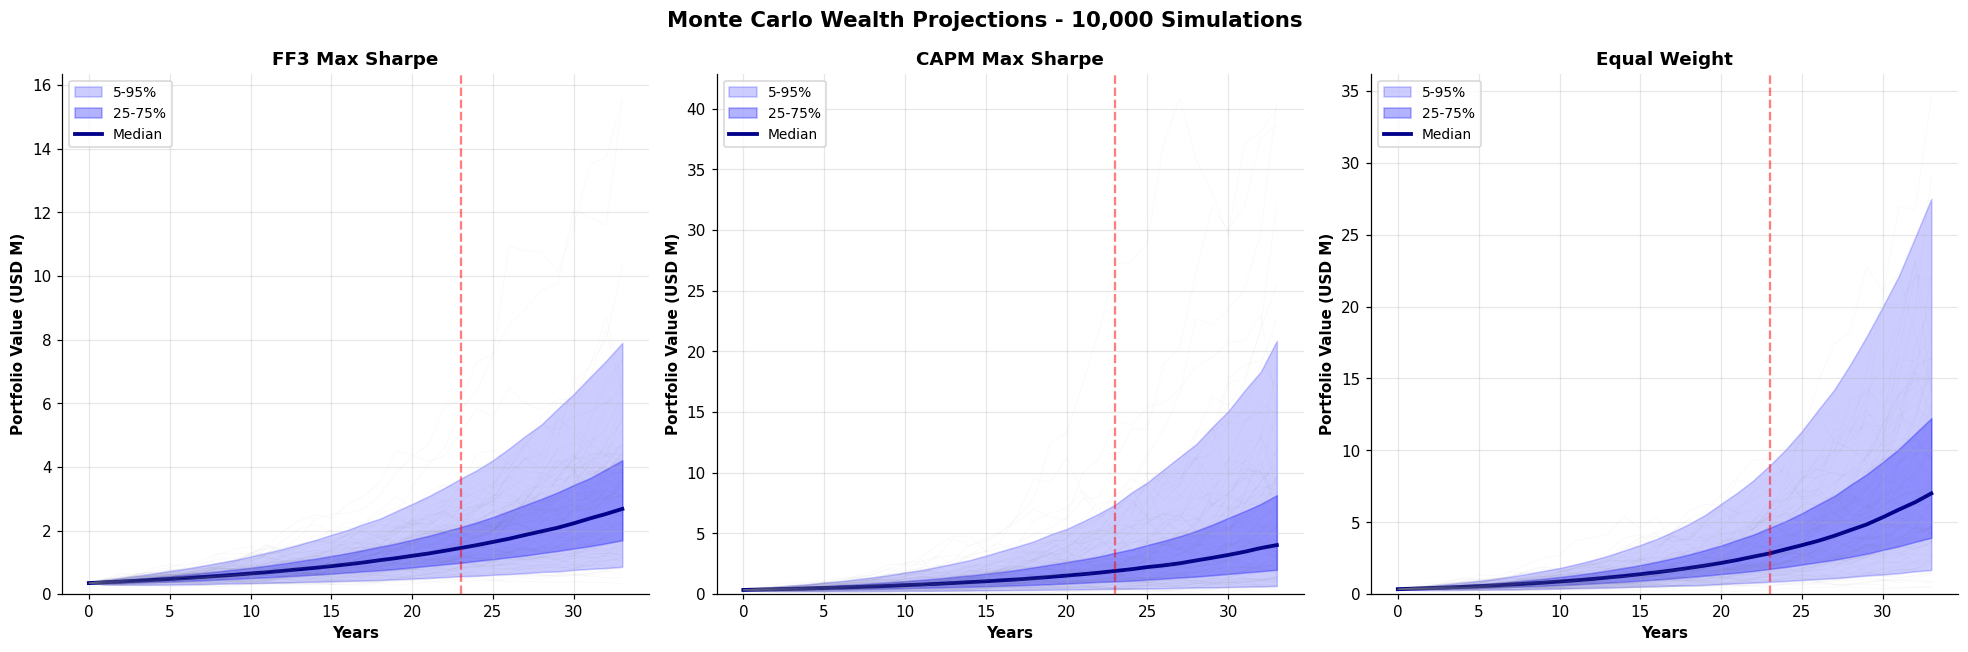

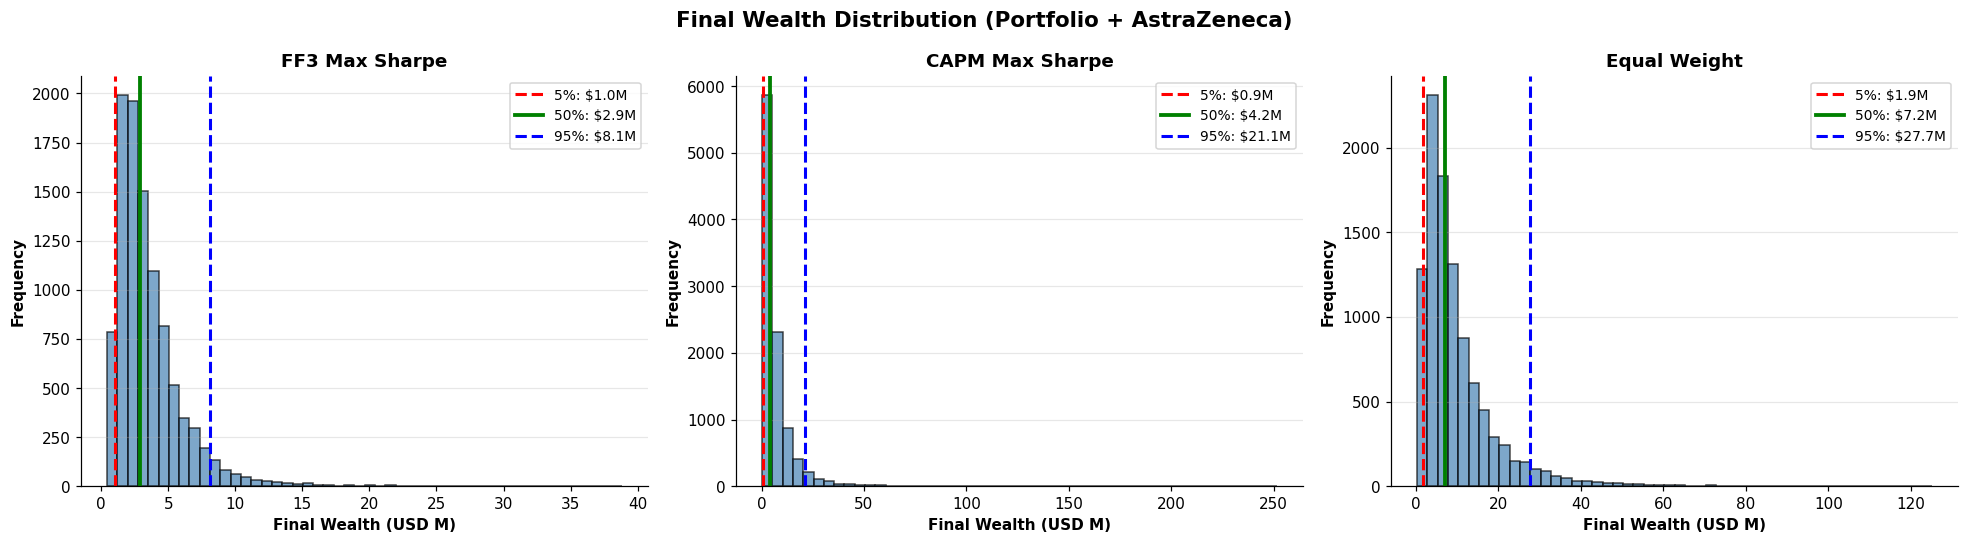

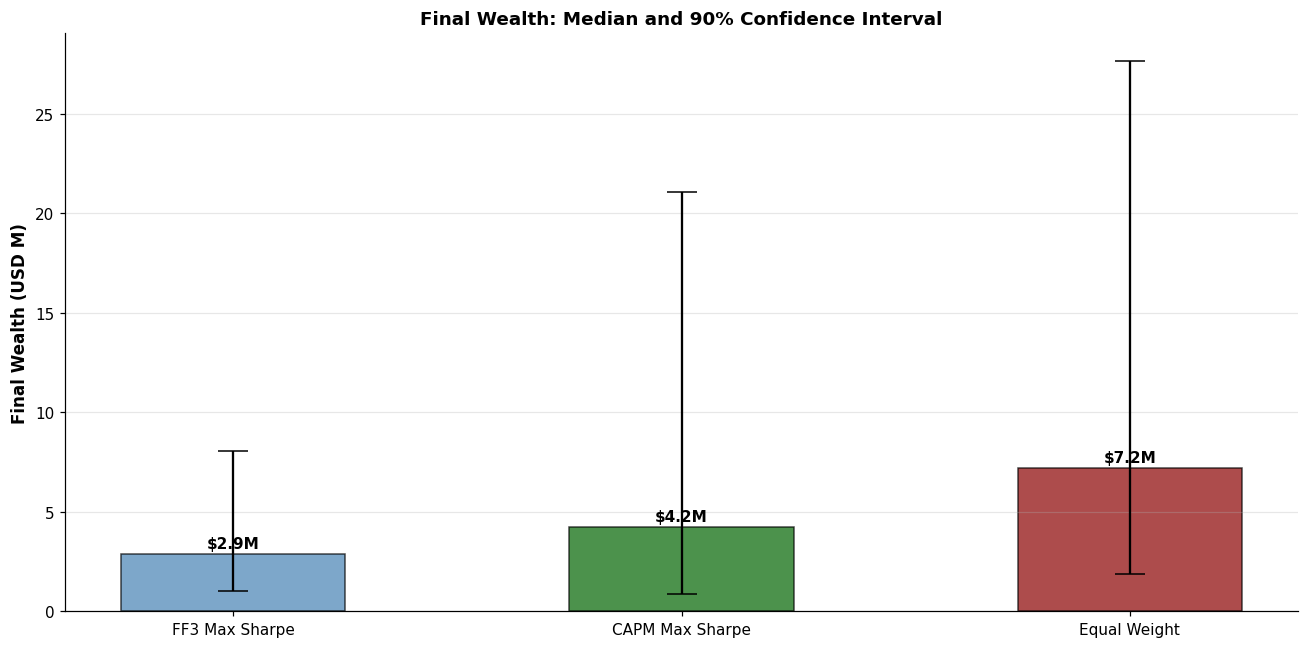


MONTE CARLO RESULTS SUMMARY

      Portfolio 5th Percentile 25th Percentile Median (50%) 75th Percentile 95th Percentile   Mean Std Dev Prob >= 3M Prob >= 4M
 FF3 Max Sharpe          $1.0M           $1.9M        $2.9M           $4.4M           $8.1M  $3.5M   $2.5M      47.0%      30.2%
CAPM Max Sharpe          $0.9M           $2.2M        $4.2M           $8.3M          $21.1M  $6.8M   $8.8M      63.8%      52.1%
   Equal Weight          $1.9M           $4.1M        $7.2M          $12.4M          $27.7M $10.0M   $9.5M      85.3%      76.0%

RETIREMENT INCOME ANALYSIS (4% Rule)

      Portfolio Monthly Income (5%) Monthly Income (50%) Monthly Income (95%)
 FF3 Max Sharpe              $3,480               $9,538              $26,930
CAPM Max Sharpe              $2,863              $14,080              $70,168
   Equal Weight              $6,205              $23,954              $92,245

INTERPRETATION

5th Percentile: Pessimistic scenario (5% chance of doing worse)
50th Percentile (Media

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ============================================================================
# MONTE CARLO SIMULATION SETUP
# ============================================================================

# Sofia's parameters
INITIAL_INVESTMENT = 350_000
ASTRAZENECA_HOLDING = 180_000
INVESTMENT_HORIZON = 33  # years
GLIDE_PATH_START = 23    # year when glide path begins (age 57)
NUM_SIMULATIONS = 10_000
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

print("=" * 100)
print("MONTE CARLO WEALTH PROJECTION - FF3, CAPM, EQUAL WEIGHT")
print("=" * 100)

# ============================================================================
# ESTIMATE PORTFOLIO PARAMETERS FROM HISTORICAL DATA
# ============================================================================

portfolios_mc = {
    'FF3 Max Sharpe': port_ff3,
    'CAPM Max Sharpe': port_capm,
    'Equal Weight': port_ew,
}

portfolio_params = {}

for name, returns in portfolios_mc.items():
    # Weekly to annual
    weekly_mean = returns.mean()
    weekly_std = returns.std()
    
    annual_mean = weekly_mean * 52
    annual_std = weekly_std * np.sqrt(52)
    
    portfolio_params[name] = {
        'mean': annual_mean,
        'std': annual_std,
        'annual_return': annual_mean,
        'annual_volatility': annual_std,
    }
    
    print(f"\n{name}:")
    print(f"  Annual Return: {annual_mean:.2%}")
    print(f"  Annual Volatility: {annual_std:.2%}")
    print(f"  Sharpe (0% rf): {annual_mean/annual_std:.3f}")

# ============================================================================
# MONTE CARLO FUNCTION
# ============================================================================

def monte_carlo_projection(mean_return, std_return, horizon, initial, num_sims, glide_path_start=23):
    """
    Simulate wealth paths with glide path (80% equity → 60%)
    """
    
    wealth_paths = np.zeros((num_sims, horizon + 1))
    wealth_paths[:, 0] = initial
    
    # Generate random returns for all years, all simulations
    random_returns = np.random.normal(
        loc=mean_return,
        scale=std_return,
        size=(num_sims, horizon)
    )
    
    # Apply glide path adjustment
    for yr in range(1, horizon + 1):
        if yr <= glide_path_start:
            equity_alloc = 0.80
        else:
            equity_alloc = max(0.80 - 0.01 * (yr - glide_path_start), 0.60)
        
        adjusted_returns = random_returns[:, yr - 1]
        wealth_paths[:, yr] = wealth_paths[:, yr - 1] * (1 + adjusted_returns)
    
    return wealth_paths

# ============================================================================
# RUN MONTE CARLO FOR EACH PORTFOLIO
# ============================================================================

print("\n" + "=" * 100)
print("RUNNING MONTE CARLO SIMULATIONS...")
print("=" * 100)

mc_results = {}

for portfolio_name, params in portfolio_params.items():
    print(f"\nSimulating {NUM_SIMULATIONS:,} paths for {portfolio_name}...")
    
    wealth_paths = monte_carlo_projection(
        mean_return=params['mean'],
        std_return=params['std'],
        horizon=INVESTMENT_HORIZON,
        initial=INITIAL_INVESTMENT,
        num_sims=NUM_SIMULATIONS,
        glide_path_start=GLIDE_PATH_START
    )
    
    final_wealth = wealth_paths[:, -1]
    final_wealth_with_asz = final_wealth + ASTRAZENECA_HOLDING
    
    # Calculate statistics
    percentiles = np.percentile(final_wealth_with_asz, [5, 25, 50, 75, 95])
    
    mc_results[portfolio_name] = {
        'wealth_paths': wealth_paths,
        'final_wealth': final_wealth,
        'final_wealth_with_asz': final_wealth_with_asz,
        'percentiles': percentiles,
        'mean': np.mean(final_wealth_with_asz),
        'std': np.std(final_wealth_with_asz),
        'prob_reach_3m': np.sum(final_wealth_with_asz >= 3_000_000) / NUM_SIMULATIONS,
        'prob_reach_4m': np.sum(final_wealth_with_asz >= 4_000_000) / NUM_SIMULATIONS,
    }
    
    print(f"  5th percentile: ${percentiles[0]:,.0f}")
    print(f"  Median: ${percentiles[2]:,.0f}")
    print(f"  95th percentile: ${percentiles[4]:,.0f}")
    print(f"  Probability of reaching USD 3M: {mc_results[portfolio_name]['prob_reach_3m']:.1%}")

# ============================================================================
# VISUALIZATION 1: WEALTH PATHS
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Monte Carlo Wealth Projections - 10,000 Simulations', fontsize=14, fontweight='bold')

for idx, (name, results) in enumerate(mc_results.items()):
    ax = axes[idx]
    
    years = np.arange(INVESTMENT_HORIZON + 1)
    
    # Calculate percentiles for each year
    perc_5 = np.percentile(results['wealth_paths'] / 1e6, 5, axis=0)
    perc_25 = np.percentile(results['wealth_paths'] / 1e6, 25, axis=0)
    perc_50 = np.percentile(results['wealth_paths'] / 1e6, 50, axis=0)
    perc_75 = np.percentile(results['wealth_paths'] / 1e6, 75, axis=0)
    perc_95 = np.percentile(results['wealth_paths'] / 1e6, 95, axis=0)
    
    # Plot confidence bands
    ax.fill_between(years, perc_5, perc_95, alpha=0.2, color='blue', label='5-95%')
    ax.fill_between(years, perc_25, perc_75, alpha=0.3, color='blue', label='25-75%')
    ax.plot(years, perc_50, color='darkblue', linewidth=2.5, label='Median')
    
    # Plot sample paths
    sample_indices = np.random.choice(NUM_SIMULATIONS, size=100, replace=False)
    for idx_sim in sample_indices:
        ax.plot(years, results['wealth_paths'][idx_sim, :] / 1e6, 
                color='gray', alpha=0.05, linewidth=0.5)
    
    ax.axvline(GLIDE_PATH_START, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
    ax.set_xlabel('Years', fontweight='bold')
    ax.set_ylabel('Portfolio Value (USD M)', fontweight='bold')
    ax.set_title(name, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend(loc='upper left', fontsize=9)
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 2: FINAL WEALTH DISTRIBUTION
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Final Wealth Distribution (Portfolio + AstraZeneca)', fontsize=14, fontweight='bold')

for idx, (name, results) in enumerate(mc_results.items()):
    ax = axes[idx]
    
    final_wealth_dist = results['final_wealth_with_asz'] / 1e6
    
    # Histogram
    ax.hist(final_wealth_dist, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    
    # Add percentile lines
    perc_5, perc_50, perc_95 = results['percentiles'][0]/1e6, results['percentiles'][2]/1e6, results['percentiles'][4]/1e6
    ax.axvline(perc_5, color='red', linestyle='--', linewidth=2, label=f'5%: ${perc_5:.1f}M')
    ax.axvline(perc_50, color='green', linestyle='-', linewidth=2.5, label=f'50%: ${perc_50:.1f}M')
    ax.axvline(perc_95, color='blue', linestyle='--', linewidth=2, label=f'95%: ${perc_95:.1f}M')
    
    ax.set_xlabel('Final Wealth (USD M)', fontweight='bold')
    ax.set_ylabel('Frequency', fontweight='bold')
    ax.set_title(name, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 3: COMPARISON OF OUTCOMES
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 6))

positions = np.arange(len(mc_results))
width = 0.25

# Extract data
medians = [mc_results[name]['percentiles'][2] / 1e6 for name in mc_results.keys()]
perc_5 = [mc_results[name]['percentiles'][0] / 1e6 for name in mc_results.keys()]
perc_95 = [mc_results[name]['percentiles'][4] / 1e6 for name in mc_results.keys()]
errors = [
    [medians[i] - perc_5[i] for i in range(len(mc_results))],
    [perc_95[i] - medians[i] for i in range(len(mc_results))]
]

bars = ax.bar(positions, medians, width=0.5, yerr=errors, capsize=10, 
              color=['steelblue', 'darkgreen', 'darkred'], alpha=0.7, edgecolor='black')

# Add value labels
for idx, (bar, med) in enumerate(zip(bars, medians)):
    ax.text(bar.get_x() + bar.get_width()/2, med + 0.15, f'${med:.1f}M',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_ylabel('Final Wealth (USD M)', fontweight='bold', fontsize=11)
ax.set_title('Final Wealth: Median and 90% Confidence Interval', fontweight='bold', fontsize=12)
ax.set_xticks(positions)
ax.set_xticklabels(mc_results.keys(), fontsize=10)
ax.grid(alpha=0.3, axis='y')
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

# ============================================================================
# SUMMARY TABLE
# ============================================================================

print("\n" + "=" * 100)
print("MONTE CARLO RESULTS SUMMARY")
print("=" * 100)

summary_data = []
for name in mc_results.keys():
    results = mc_results[name]
    percentiles = results['percentiles']
    
    summary_data.append({
        'Portfolio': name,
        '5th Percentile': f"${percentiles[0]/1e6:.1f}M",
        '25th Percentile': f"${percentiles[1]/1e6:.1f}M",
        'Median (50%)': f"${percentiles[2]/1e6:.1f}M",
        '75th Percentile': f"${percentiles[3]/1e6:.1f}M",
        '95th Percentile': f"${percentiles[4]/1e6:.1f}M",
        'Mean': f"${results['mean']/1e6:.1f}M",
        'Std Dev': f"${results['std']/1e6:.1f}M",
        'Prob >= 3M': f"{results['prob_reach_3m']:.1%}",
        'Prob >= 4M': f"{results['prob_reach_4m']:.1%}",
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

# ============================================================================
# RETIREMENT INCOME ANALYSIS
# ============================================================================

print("\n" + "=" * 100)
print("RETIREMENT INCOME ANALYSIS (4% Rule)")
print("=" * 100)

income_data = []
for name in mc_results.keys():
    results = mc_results[name]
    percentiles = results['percentiles']
    
    # 4% rule
    income_5pct = (percentiles[0] * 0.04) / 12  # Monthly
    income_50pct = (percentiles[2] * 0.04) / 12
    income_95pct = (percentiles[4] * 0.04) / 12
    
    income_data.append({
        'Portfolio': name,
        'Monthly Income (5%)': f"${income_5pct:,.0f}",
        'Monthly Income (50%)': f"${income_50pct:,.0f}",
        'Monthly Income (95%)': f"${income_95pct:,.0f}",
    })

income_df = pd.DataFrame(income_data)
print("\n" + income_df.to_string(index=False))

print("\n" + "=" * 100)
print("INTERPRETATION")
print("=" * 100)
print("""
5th Percentile: Pessimistic scenario (5% chance of doing worse)
50th Percentile (Median): Most likely outcome
95th Percentile: Optimistic scenario (5% chance of doing better)

Monthly Income: Based on 4% rule (annual withdrawal / 12)
The range shows the distribution of possible retirement income outcomes.

Probability >= 3M / 4M: Chance of reaching specific wealth targets
Higher probability indicates more robust portfolio for Sofia's needs.
""")